# DEF-D Fysieke Ontwerpopdracht 4 invul template
Aan het einde van deze ontwerpopdracht lever je als groep één gezamenlijk notebook in. Zet jullie groepsnummer, studienummers en namen in onderstaande tabel zodat wij zeker weten dat het groepsvormen goed is gegaan.

| Groep: 07     |  |
| :-------------|:-------------|
| Lieke Boontjes| 6543715 |
| Yu He Zhang| 6455417 |
| Zulfiqar Alwani| 6281265 |

In [1]:
# Vul ook hieronder jullie voornamen in en run deze cel.
# Dat is nodig voor de code die je verderop in dit notebook gaat runnen.

studentNames = ['Lieke', 'Yu He','Zul']

## Opdracht 1: Planning.

| Planning Groep: 7     |Tijdstip / Tijdspanne  |
|---|---|
| kalibreren | 11:00-11:15 |
| testen meetopstelling | 11:15-12:00 |
| individueel algoritme | 12:00-12:30 |
| pauze | 12:30-13:30 |
| itereren | 13:30-16:00 |
| conclusies en afronden | 16:00-eind |
| groep aanwezig 1| 11:00 |
| groep aanwezig 2| 13:30 |
| Pauze 1| 12:30-13:30 |
| Pauze 2| 15:00-15:15 |

## Opdracht 2: Import libs.

In [2]:
%matplotlib inline
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
import random
import time

# Dit is onze eigen library waar het imaging algoritme in staat
import imagingDEF2024 as imagingDEF

## Opdracht 3: Kalibratie sensor en foto

kalibratie-opstelling groep [7]
<img src="opstellingopdracht4.jpeg" width="400">


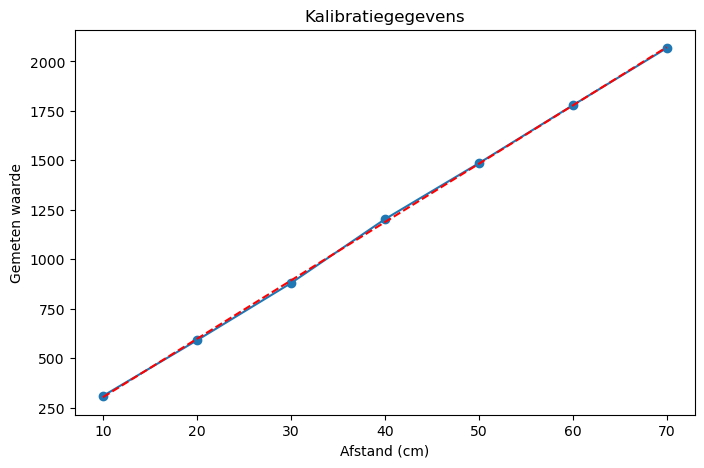

Kalibratieparameters: a = 29.485714285714288 b = 7.714285714285391


In [3]:
from scipy.optimize import curve_fit
import matplotlib.pyplot as plt
afstand = np.array([ 0.10, 0.20, 0.30, 0.40, 0.50, 0.60, 0.70 ])*100 # in cm
metingen_kalibratie = np.array([ 309, 590, 879, 1202,1485, 1778, 2067])

def lineaire_functie(x, a, b): 
    return a * x + b
params, covariance = curve_fit(lineaire_functie, afstand, metingen_kalibratie)

plt.figure(figsize=(8, 5))
plt.plot(afstand, metingen_kalibratie, 'o-')
plt.plot(afstand, lineaire_functie(afstand, *params), 'r--', label='Fit: a=%.2f, b=%.2f' % tuple(params))
plt.xlabel('Afstand (cm)')
plt.ylabel('Gemeten waarde')
plt.title('Kalibratiegegevens')
plt.show()
print("Kalibratieparameters: a =", params[0], "b =", params[1])


#in arduino voeren we als alpha in 0.0294857 en als beta 0.77142
#zie output van kalibratieparameters hieronder geprint




## Opdracht 4: Test meeting

Running the imaging algorithm with the following data:
   xs  ys  xr  yr      R
0   0  40   0  30  36.80
1   0  30   0  20  37.93
2  40   0  30   0  37.19
3  30   0  20   0  37.80
4  10   0  20   0  42.75


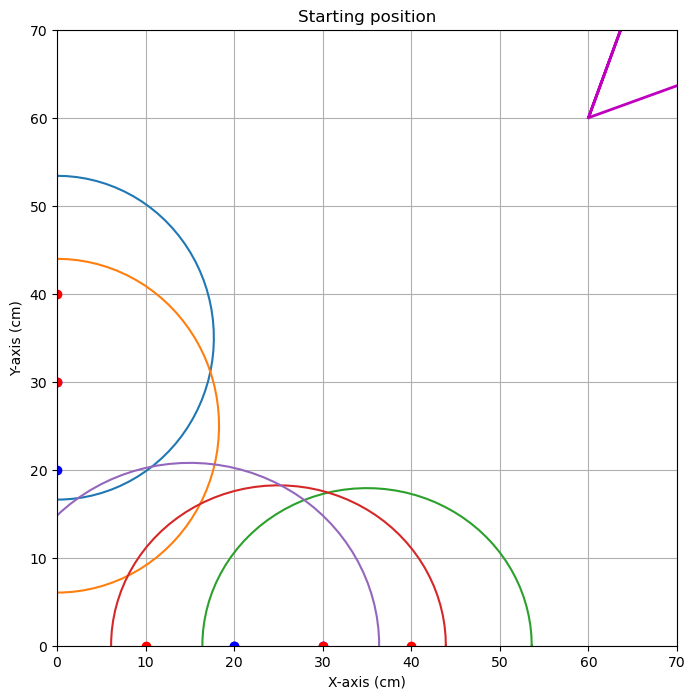


Wacht tot berekeningen klaar zijn; er komen  30 iteraties ...

end iteration 1 with average mismatch=106.770


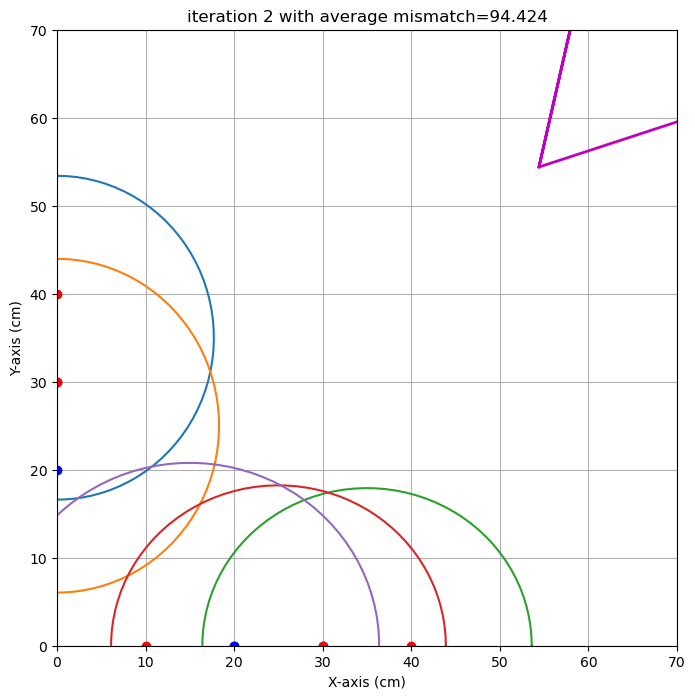

end iteration 2 with average mismatch=94.424


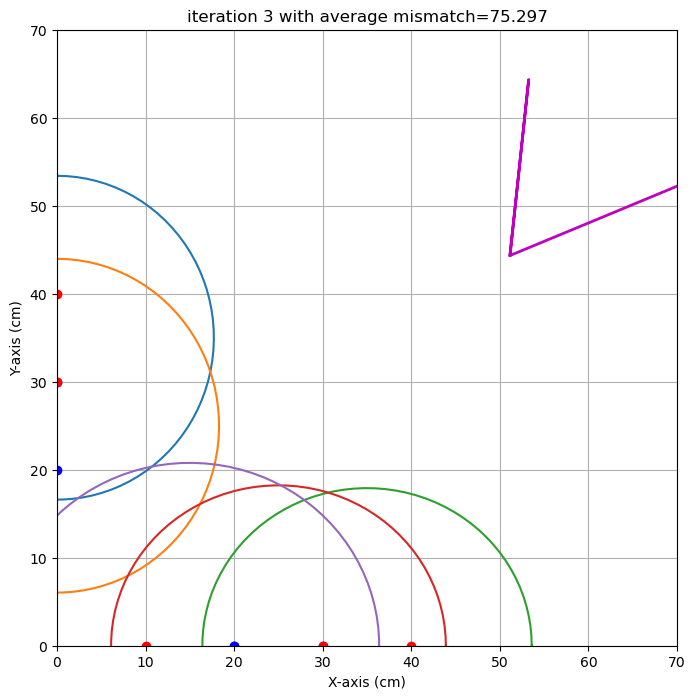

end iteration 3 with average mismatch=75.297


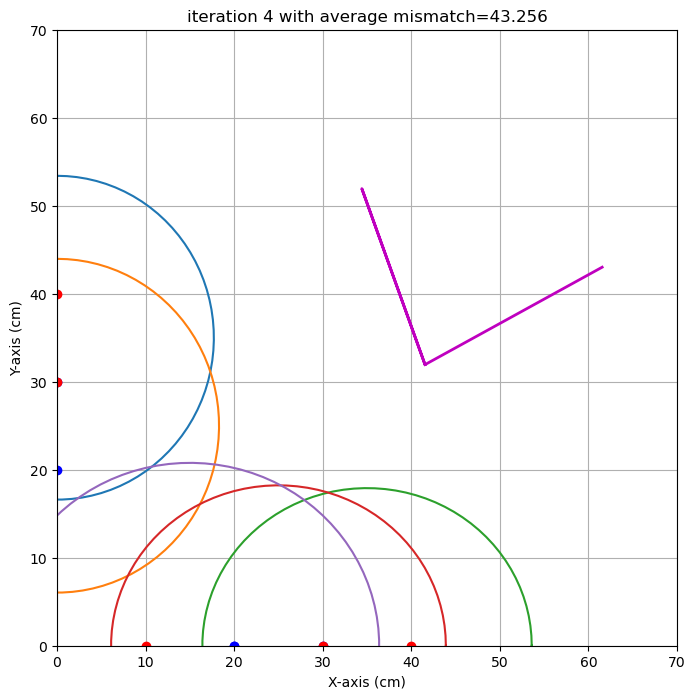

end iteration 4 with average mismatch=43.256


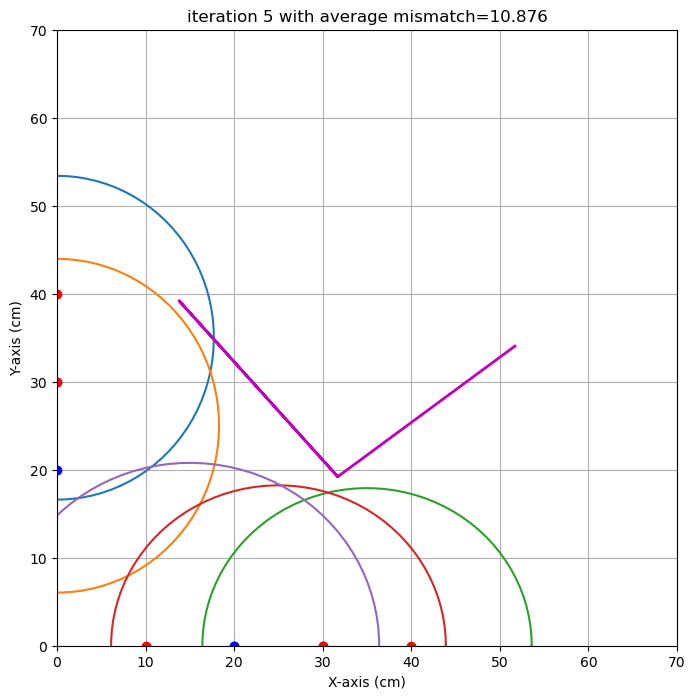

end iteration 5 with average mismatch=10.876


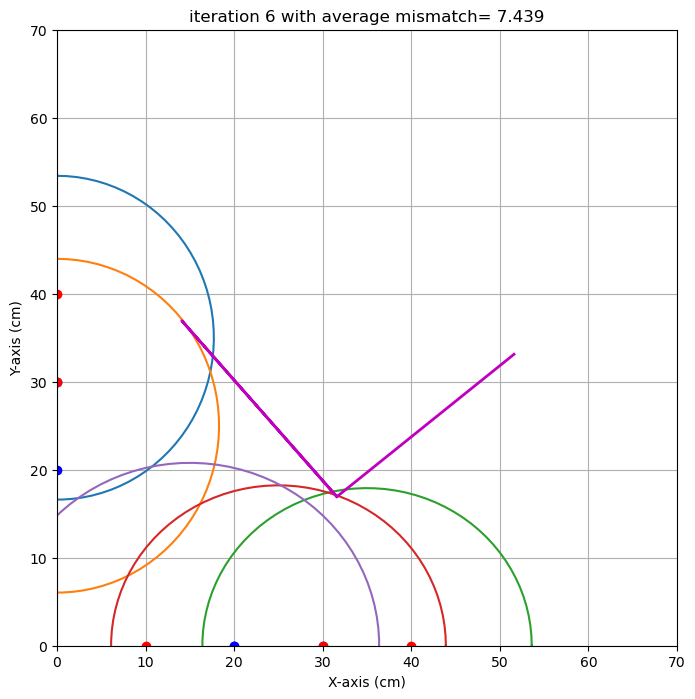

end iteration 6 with average mismatch= 7.439
end iteration 7 with average mismatch= 7.399
end iteration 8 with average mismatch= 7.395
end iteration 9 with average mismatch= 7.323
end iteration 10 with average mismatch= 6.936
end iteration 11 with average mismatch= 6.504


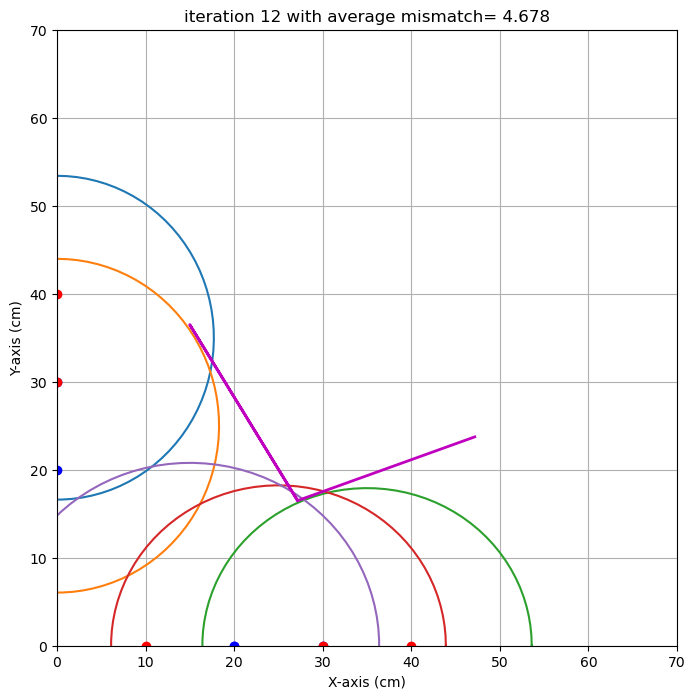

end iteration 12 with average mismatch= 4.678
end iteration 13 with average mismatch= 4.598
end iteration 14 with average mismatch= 4.466
end iteration 15 with average mismatch= 4.407
end iteration 16 with average mismatch= 4.405
end iteration 17 with average mismatch= 4.381
end iteration 18 with average mismatch= 4.381
end iteration 19 with average mismatch= 4.381
end iteration 20 with average mismatch= 4.381
end iteration 21 with average mismatch= 4.381
end iteration 22 with average mismatch= 4.381
end iteration 23 with average mismatch= 4.381
end iteration 24 with average mismatch= 4.380
end iteration 25 with average mismatch= 4.380
end iteration 26 with average mismatch= 4.380
end iteration 27 with average mismatch= 4.380
end iteration 28 with average mismatch= 4.380
end iteration 29 with average mismatch= 4.380
Last iteration, also determine uncertainty, wait a while..
wait a little longer....
wait a little longer....


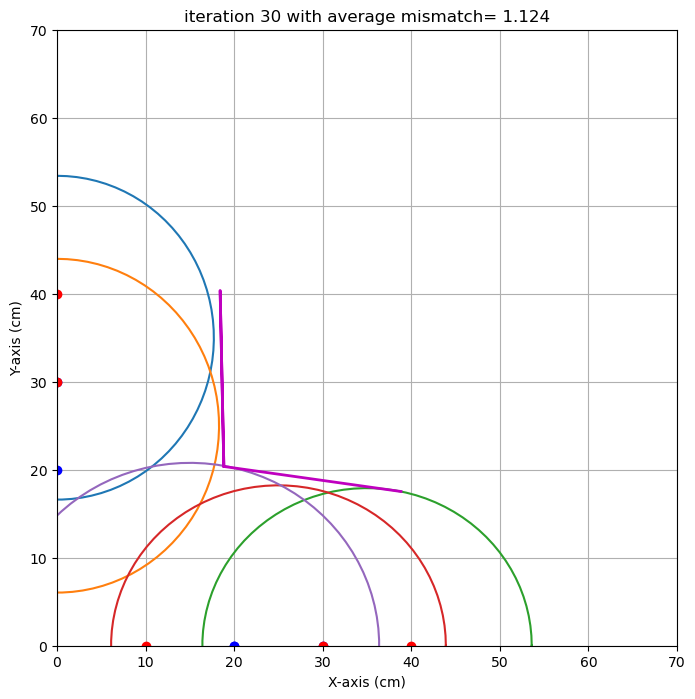

end iteration 30 with average mismatch= 1.124
###############################################################################
end of iteration  30
Best alpha=  -8.09 with uncertainty=   1.63
Best beta =  -1.20 with uncertainty=   4.01
Best x0   =  18.83 with uncertainty=   0.71
Best y0   =  20.37 with uncertainty=   0.23
###############################################################################


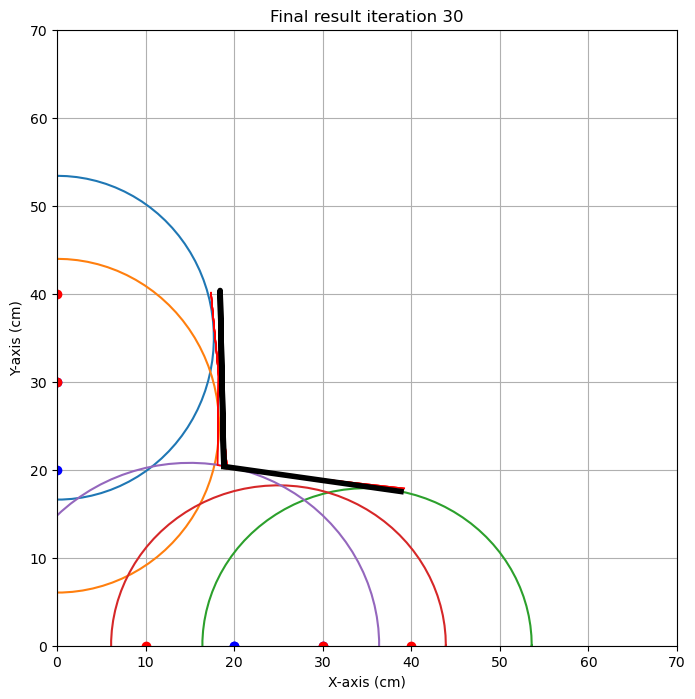

In [4]:
# Vul onderstaande matrixen aan met jullie meetgegevens.
# De getallen 1.0, 2.0, 3.0, 4.0, 5.0, 6.0 en 7.0 moet je door je eigen metingen (in cm!) vervangen.
# Let op dat de meting een totale afstand die het geluid afgelegd heeft moet zijn.

# Als je ongeldige metingen hebt (denk aan het college!), zet ze dan wel in het dataframe hieronder,
# maar gebruik een '#' om de regel uit te commenteren, zoals we bij de laatste meting voorgedaan hebben.

                
dataSanityCheck = pd.DataFrame(columns=["xs", "ys", "xr", "yr", "R"], data=[
    [0,40,0,30,36.80],
    [0,30,0,20,37.93],
    #[0,10,0,20,77.71], deze meet niks
    [40,0,30,0,37.19],
    [30,0,20,0,37.80],
    [10,0,20,0,42.75],
    #[10,0,0,10,150.70]  # ontvanger en bron staan beetje gedraaid, anders geen datapunt gegenereerd door arduino krijgen te gote waars reflecteerd dus niet op papier 
    ])

resultaatSanityCheck = imagingDEF.imagingDEF(dataSanityCheck)

In [5]:
# Run deze cel om jullie resultaten te kunnen zien.
txt='x0: {x0:.1f} cm met een standaardafwijking van {x0_eps:.1f} cm \r\n'
txt = txt + 'y0: {y0:.1f} cm met een standaardafwijking van {y0_eps:.1f} cm \r\n'
txt = txt + 'alpha: {alpha:.1f} graden met een standaardafwijking van {alpha_eps:.1f} graad \r\n'
txt = txt + 'beta: {beta:.1f} graden met een standaardafwijking van {beta_eps:.1f} graad \r\n'
print(txt.format(x0=resultaatSanityCheck['x0'],
                 x0_eps=resultaatSanityCheck['x0_eps'],
                 y0=resultaatSanityCheck['y0'],
                 y0_eps=resultaatSanityCheck['y0_eps'],
                 alpha=resultaatSanityCheck['alpha'],
                 alpha_eps=resultaatSanityCheck['alpha_eps'],
                 beta=resultaatSanityCheck['beta'],
                 beta_eps=resultaatSanityCheck['beta_eps']))

x0: 18.8 cm met een standaardafwijking van 0.7 cm 
y0: 20.4 cm met een standaardafwijking van 0.2 cm 
alpha: -8.1 graden met een standaardafwijking van 1.6 graad 
beta: -1.2 graden met een standaardafwijking van 4.0 graad 



## Opdracht 5: Iteratie 0

#### algoritme [Yu He Zhang]
Voeg een foto in van het algoritme van het eerste groepslid
<img src="AlgoritmeDEF4YuHe.png" width="400">

#### algoritme [Zul]
Voeg een foto in van het algoritme van het tweede groepslid
<img src="AlgoritmeDEFzul.jpg" width="400">

#### algoritme [Lieke]
Voeg een foto in van het algoritme van het derde groepslid
<img src="AlgoritmeDEF4moi.jpg" width="400">

In [6]:
# Voeg hier eventueel code toe die je nodig hebt om je algoritme uit te voeren. Dit is optioneel!

## Opdracht 6: Test iteratie 0.

Running the imaging algorithm with the following data:
   xs  ys  xr  yr      R
0  10   0  20   0   66.2
1  30   0  20   0   60.4
2  40   0  20   0   59.4
3  50   0  20   0   62.2
4   0  10   0  20   46.2
5   0  20   0  25  129.1
6   0  30   0  20  132.0


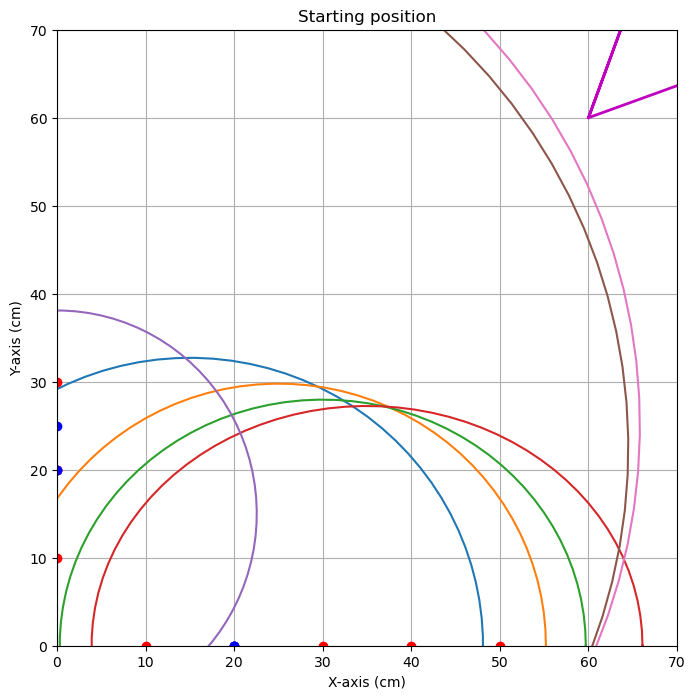


Wacht tot berekeningen klaar zijn; er komen  30 iteraties ...

end iteration 1 with average mismatch=69.555


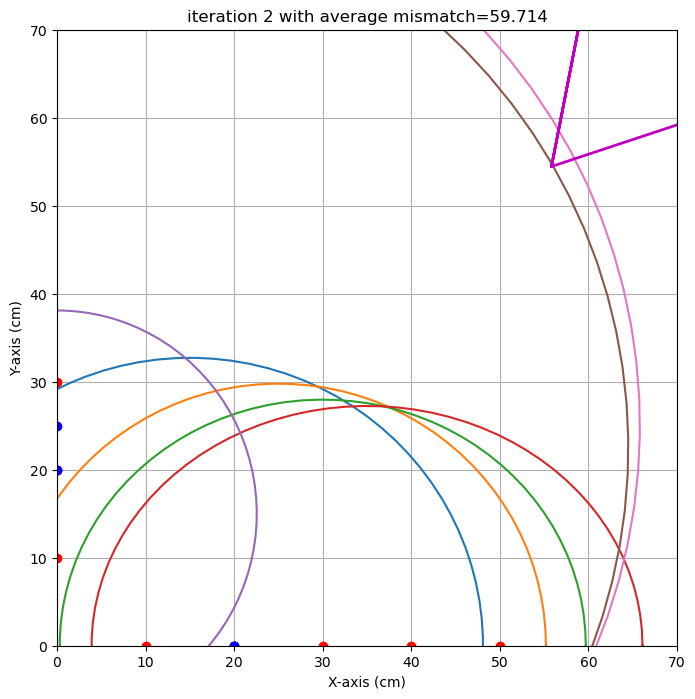

end iteration 2 with average mismatch=59.714


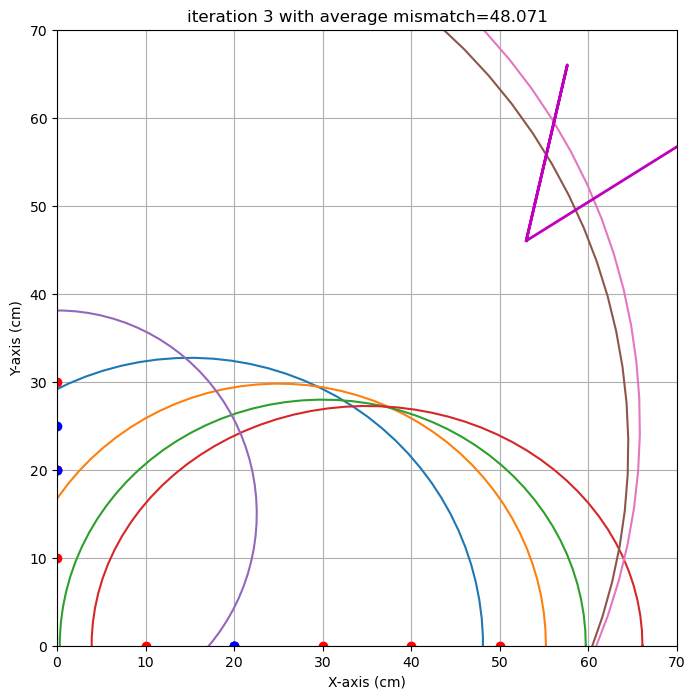

end iteration 3 with average mismatch=48.071


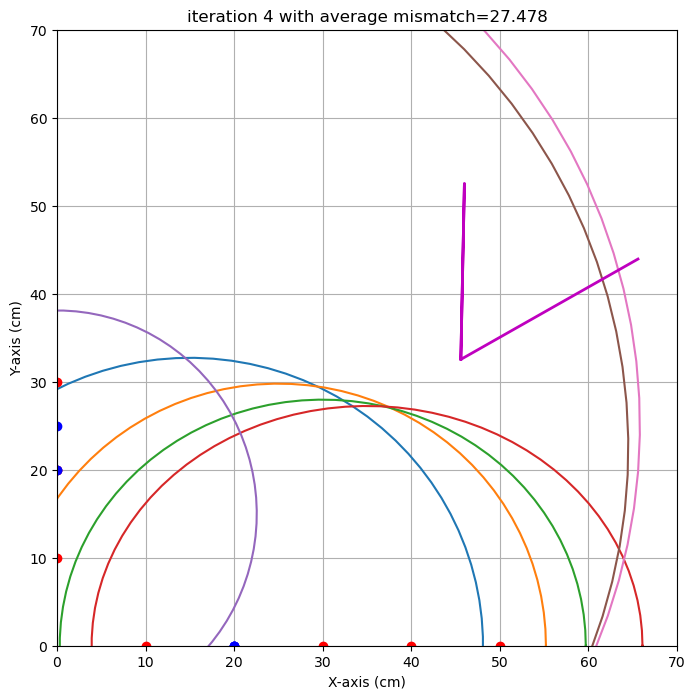

end iteration 4 with average mismatch=27.478


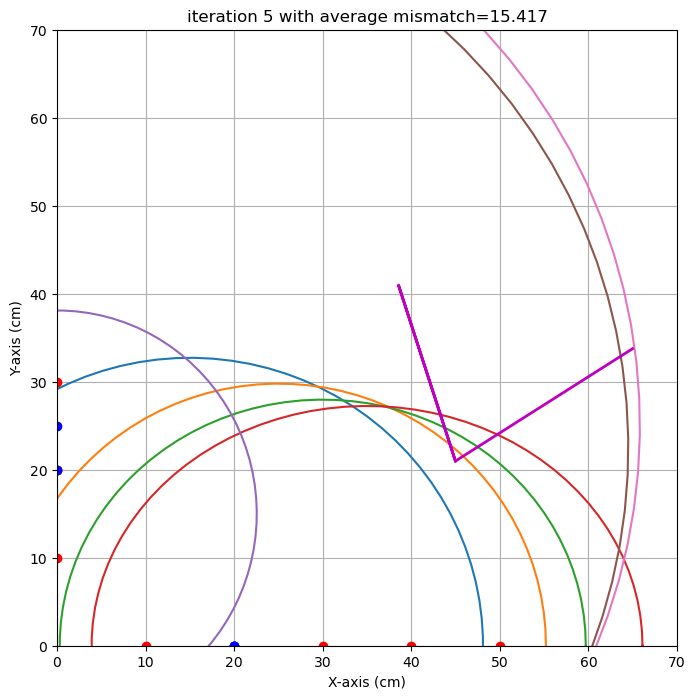

end iteration 5 with average mismatch=15.417


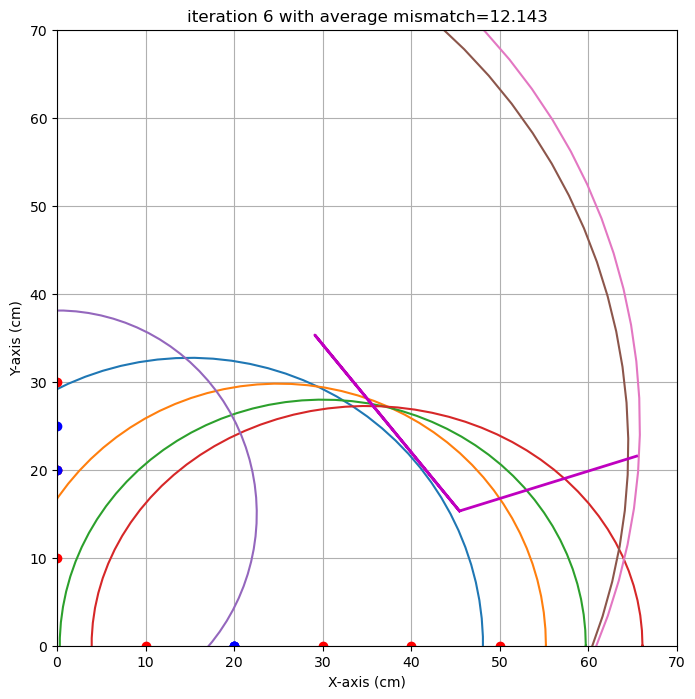

end iteration 6 with average mismatch=12.143
end iteration 7 with average mismatch=11.954
end iteration 8 with average mismatch=11.816
end iteration 9 with average mismatch=11.769
end iteration 10 with average mismatch=11.725
end iteration 11 with average mismatch=11.636
end iteration 12 with average mismatch=11.636
end iteration 13 with average mismatch=11.636
end iteration 14 with average mismatch=11.636
end iteration 15 with average mismatch=11.636
end iteration 16 with average mismatch=11.636
end iteration 17 with average mismatch=11.636
end iteration 18 with average mismatch=11.636
end iteration 19 with average mismatch=11.636
end iteration 20 with average mismatch=11.636
end iteration 21 with average mismatch=11.636
end iteration 22 with average mismatch=11.636
end iteration 23 with average mismatch=11.636
end iteration 24 with average mismatch=11.636
end iteration 25 with average mismatch=11.636
end iteration 26 with average mismatch=11.636
end iteration 27 with average mismatch

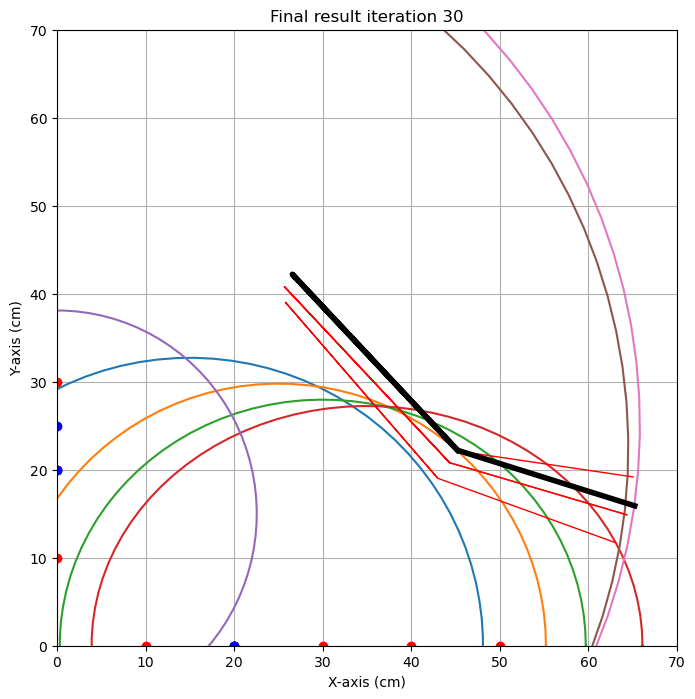

In [7]:
# Voeg hier je meetgegevens van deze iteratie in:

# Vul onderstaande in met jullie gekozen posities van het reflecterende papier
targets = {'x0':23,  #zelf aanvullen,
           'y0':45, #zelf aanvullen,
           'alpha' : -20, #zelf aanvullen,
           'beta' : 45, #zelf aanvullen},
          }
           

# Vul onderstaande matrixen aan met je gemeten meetgegevens. Als je twee algoritmes test, haal dan het hele blok
# bij 'naam3' weg. Zorg natuurlijk dat de arrays en structures netjes afsluiten met ), ] of } op de juiste plekken.

data ={'Yu He' :  pd.DataFrame(columns=["xs", "ys", "xr", "yr", "R"], data=[
    [30,0,50,0,167.57],
   #[30,0,70,0, ], geen resultaat
   #[50,0,70,0, ], geen resultaat
   [0,30,0,50,130.7 ], 
   [0,30,0,70, 80 ],
   [0,50,0,70, 67 ],
    #zelf aanvullen
    ]),
       'Lieke' : pd.DataFrame(columns=["xs", "ys", "xr", "yr", "R"], data=[
   #[40,0,0,40, 51.6],
   [0,40,0,60, 55.8], 
   #[0,35,0,50,128.0 ], 
   [10,0,25,0, 65.1 ], 
   [15,0,35,0, 62.1 ],
   #[0,50,0,70, ],
    #zelf aanvullen
    ]),
       'Zul' : pd.DataFrame(columns=["xs", "ys", "xr", "yr", "R"], data=[
    #zelf aanvullen, datapunten op x-as van de transmitter constant laten toenemen, en zelfde principe op de 5 punten op de y-as
    #Daarnaast datapunt van receiver constant gehouden, voor hopelijk betrouwbare beginmetingen, en kleinere onzekerheid in alpha en beta
    [10,0,20,0, 66.2],
   #[25,0,20,0, 61.3 ], 
   [30,0,20,0, 60.4 ], 
   [40,0,20,0, 59.4], 
   [50,0,20,0, 62.2 ],
   [0,10,0,20, 46.2 ],
   [0,20,0,25, 129.1 ], 
   [0,30,0,20, 132.0 ], 
   #[0,40,0,20, 103.8 ], 
   #[0,50,0,20, 113.4 ], 
    ])
      }



resultaatalgor1itteratie1 = imagingDEF.imagingDEF(data.get('Zul'))

## Opdracht 7: Evaluatie.

Lieke
Running the imaging algorithm with the following data:
   xs  ys  xr  yr     R
0   0  40   0  60  55.8
1  10   0  25   0  65.1
2  15   0  35   0  62.1


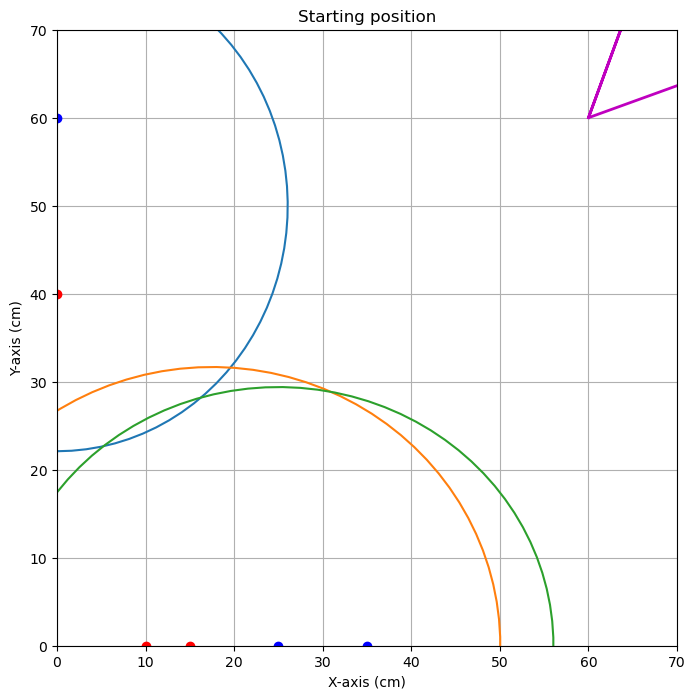


Wacht tot berekeningen klaar zijn; er komen  30 iteraties ...

end iteration 1 with average mismatch=82.642


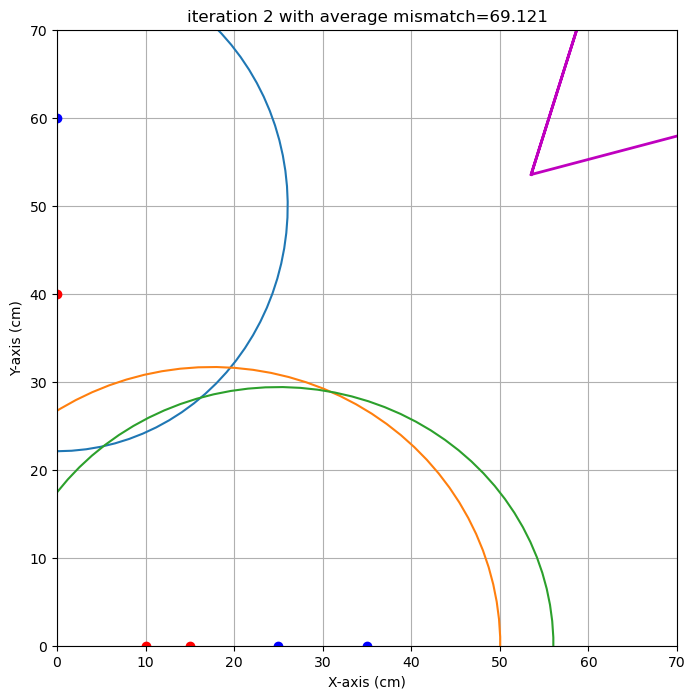

end iteration 2 with average mismatch=69.121


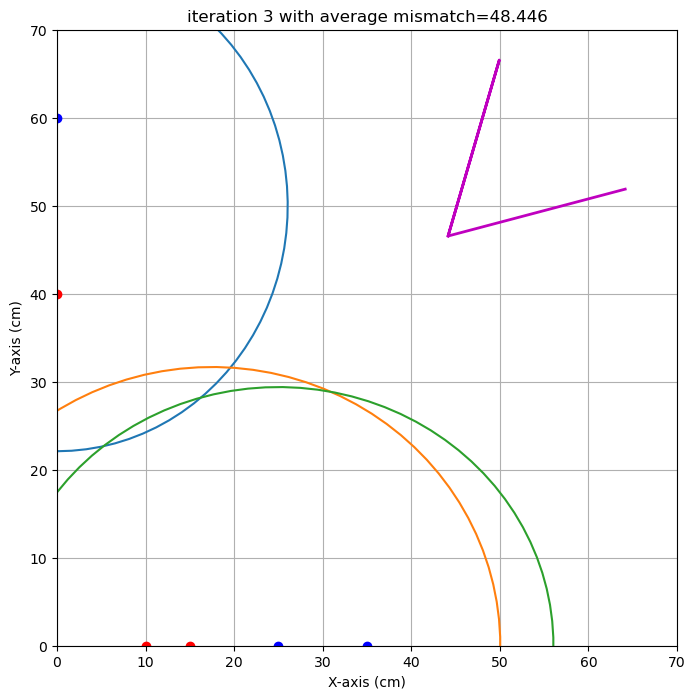

end iteration 3 with average mismatch=48.446


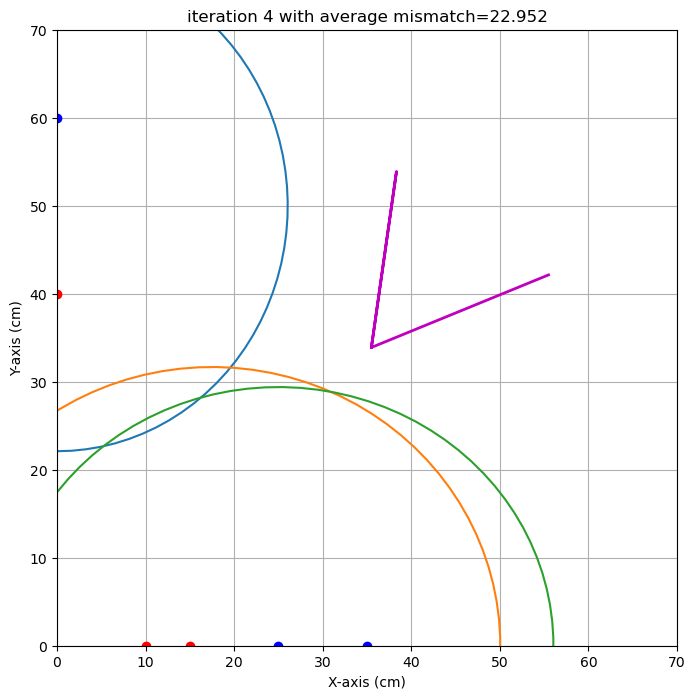

end iteration 4 with average mismatch=22.952


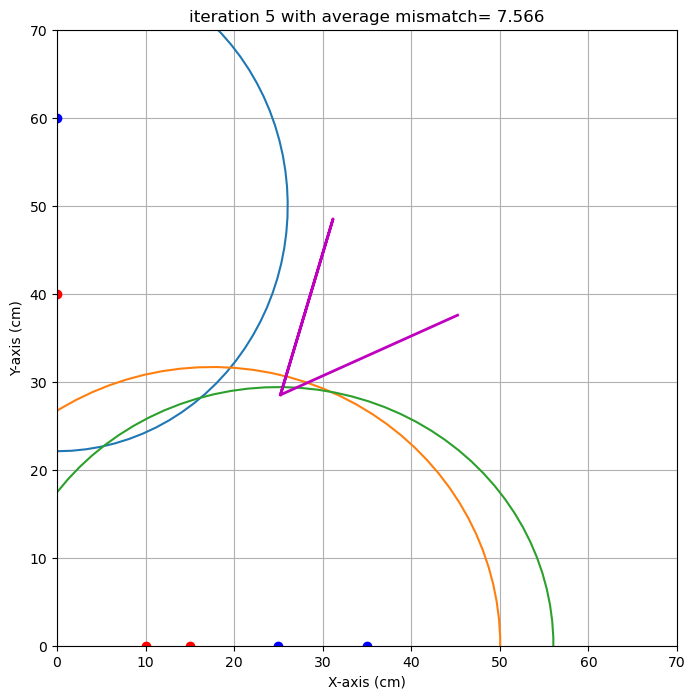

end iteration 5 with average mismatch= 7.566


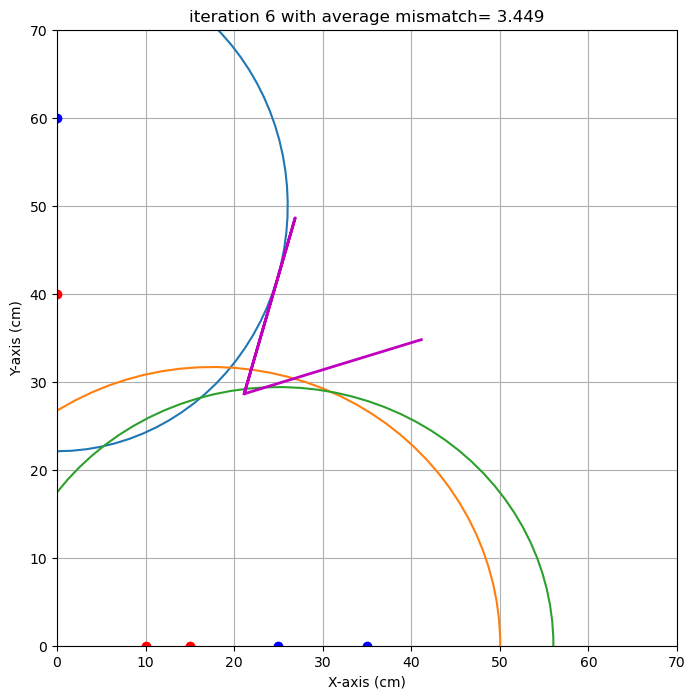

end iteration 6 with average mismatch= 3.449


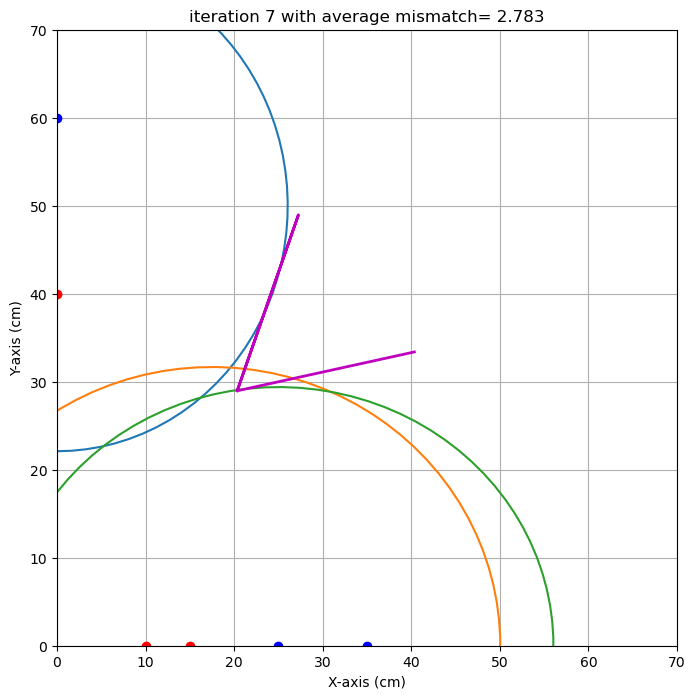

end iteration 7 with average mismatch= 2.783


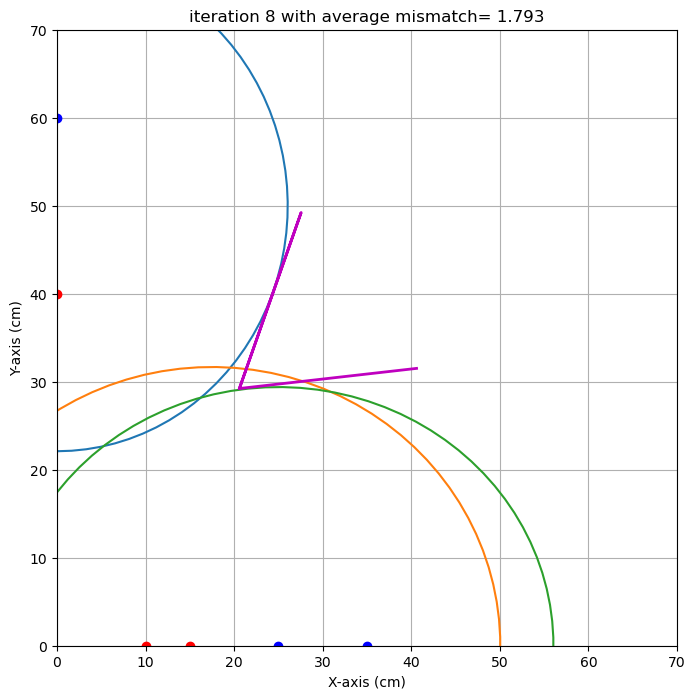

end iteration 8 with average mismatch= 1.793
end iteration 9 with average mismatch= 1.785
end iteration 10 with average mismatch= 1.785
end iteration 11 with average mismatch= 1.785
end iteration 12 with average mismatch= 1.785
end iteration 13 with average mismatch= 1.768
end iteration 14 with average mismatch= 1.708
end iteration 15 with average mismatch= 1.685
end iteration 16 with average mismatch= 1.603
end iteration 17 with average mismatch= 1.602
end iteration 18 with average mismatch= 1.602
end iteration 19 with average mismatch= 1.602
end iteration 20 with average mismatch= 1.602
end iteration 21 with average mismatch= 1.602
end iteration 22 with average mismatch= 1.602
end iteration 23 with average mismatch= 1.577
end iteration 24 with average mismatch= 1.543
end iteration 25 with average mismatch= 1.543
end iteration 26 with average mismatch= 1.543
end iteration 27 with average mismatch= 1.543
end iteration 28 with average mismatch= 1.543
end iteration 29 with average mismat

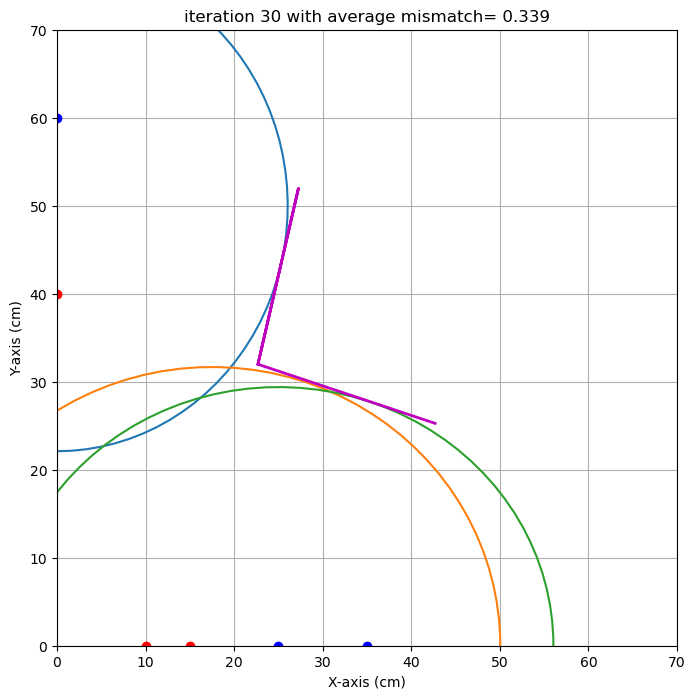

end iteration 30 with average mismatch= 0.339
###############################################################################
end of iteration  30
Best alpha= -18.56 with uncertainty=   5.55
Best beta =  12.89 with uncertainty=  13.82
Best x0   =  22.68 with uncertainty=   2.62
Best y0   =  31.98 with uncertainty=   0.70
###############################################################################


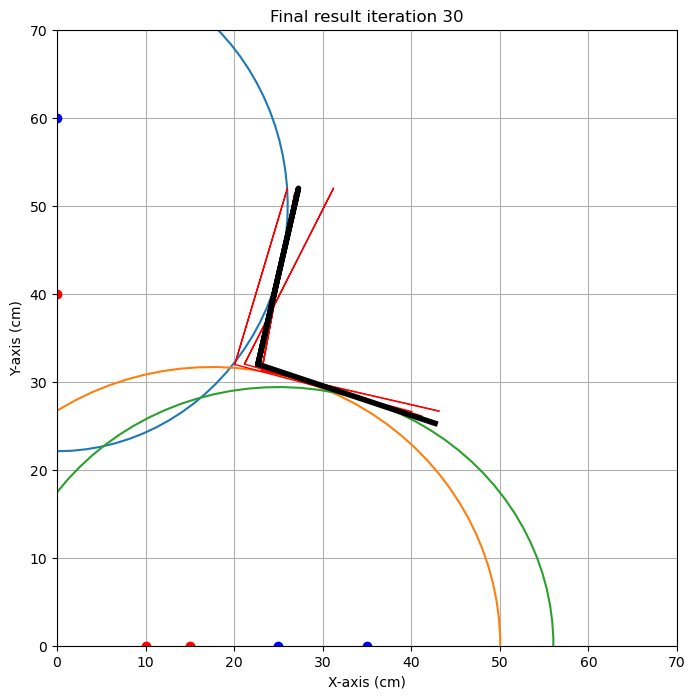

{'alpha': np.float64(-18.556764606280574), 'alpha_eps': np.float64(5.554184926850574), 'beta': np.float64(12.887575888564896), 'beta_eps': np.float64(13.824259451285421), 'x0': np.float64(22.682554615577057), 'x0_eps': np.float64(2.61822594866549), 'y0': np.float64(31.98471669563839), 'y0_eps': np.float64(0.6998820512718993)}
Yu He
Running the imaging algorithm with the following data:
   xs  ys  xr  yr     R
0   0  40   0  60  55.8
1  10   0  25   0  65.1
2  15   0  35   0  62.1


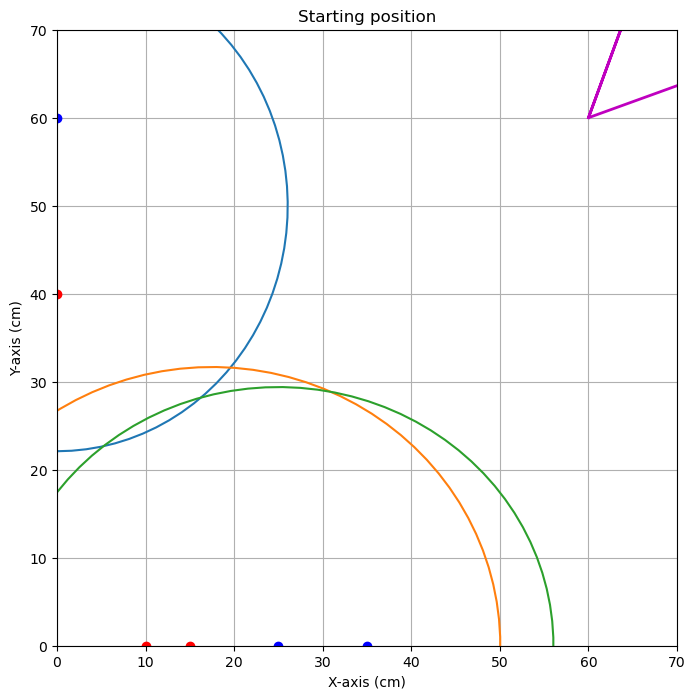


Wacht tot berekeningen klaar zijn; er komen  30 iteraties ...

end iteration 1 with average mismatch=82.642


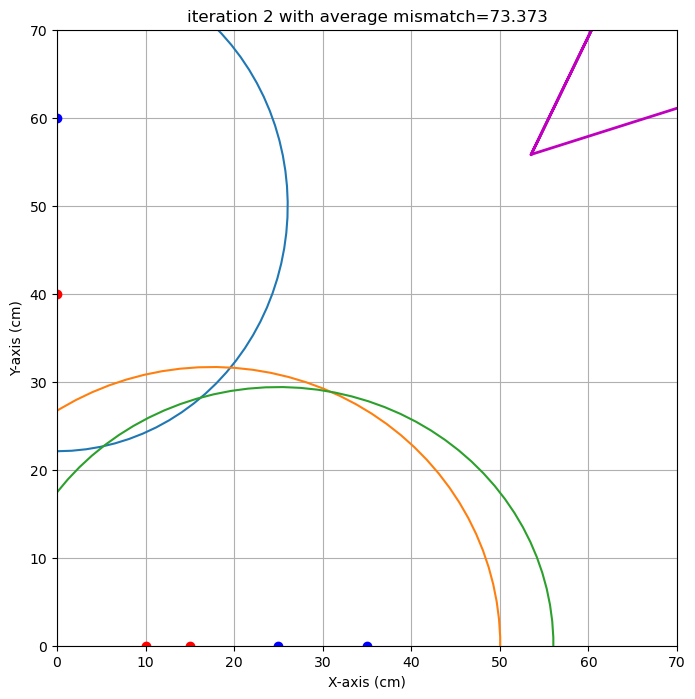

end iteration 2 with average mismatch=73.373


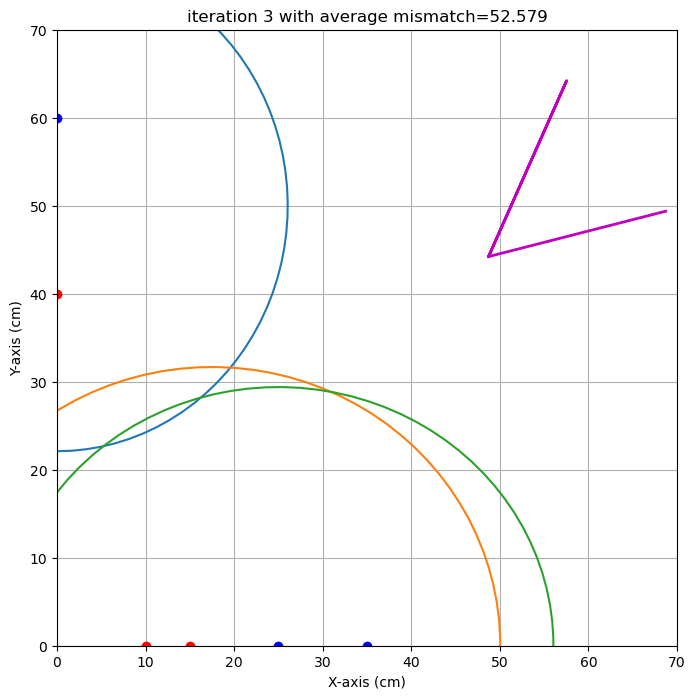

end iteration 3 with average mismatch=52.579


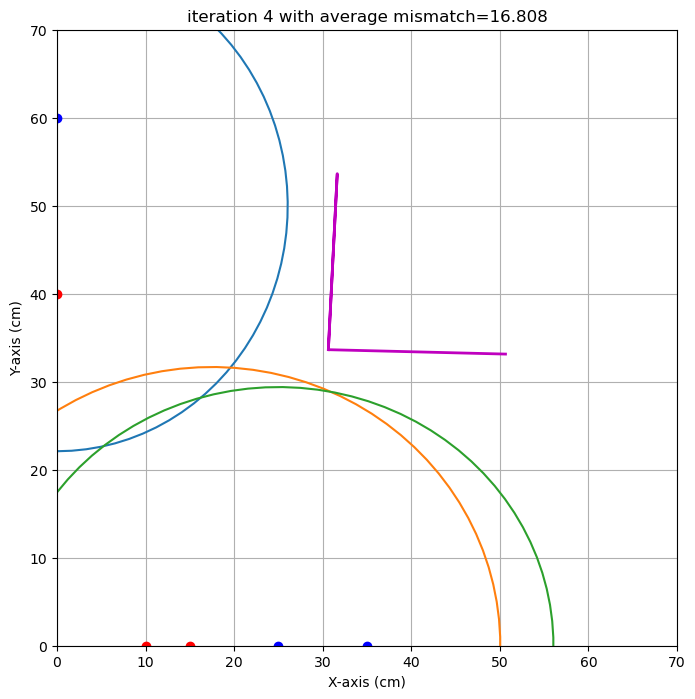

end iteration 4 with average mismatch=16.808


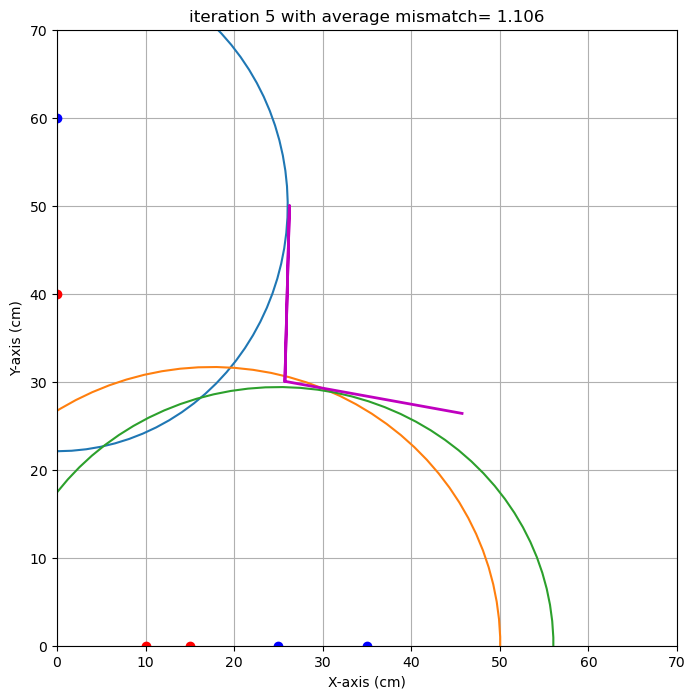

end iteration 5 with average mismatch= 1.106


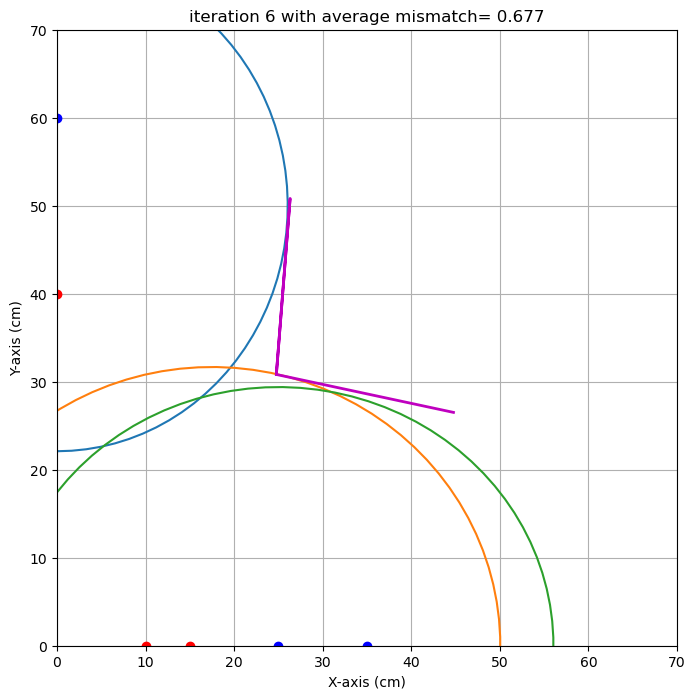

end iteration 6 with average mismatch= 0.677


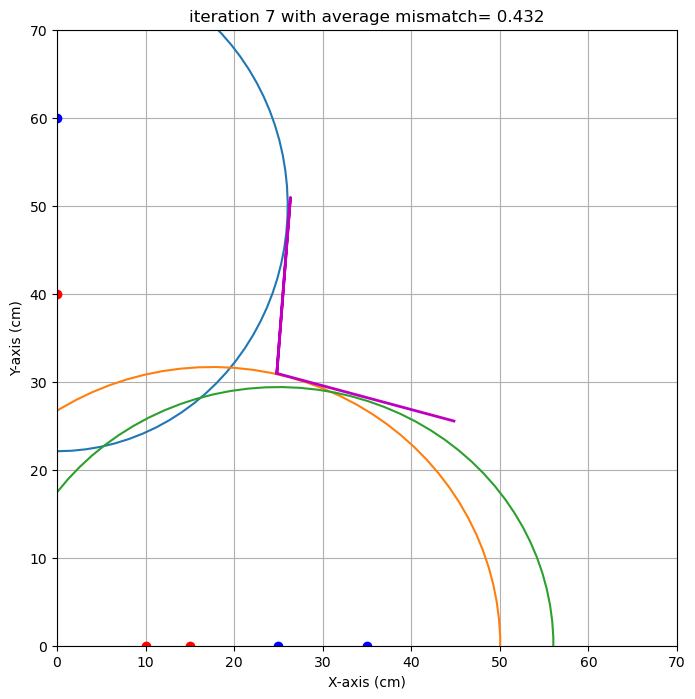

end iteration 7 with average mismatch= 0.432
end iteration 8 with average mismatch= 0.422
end iteration 9 with average mismatch= 0.412


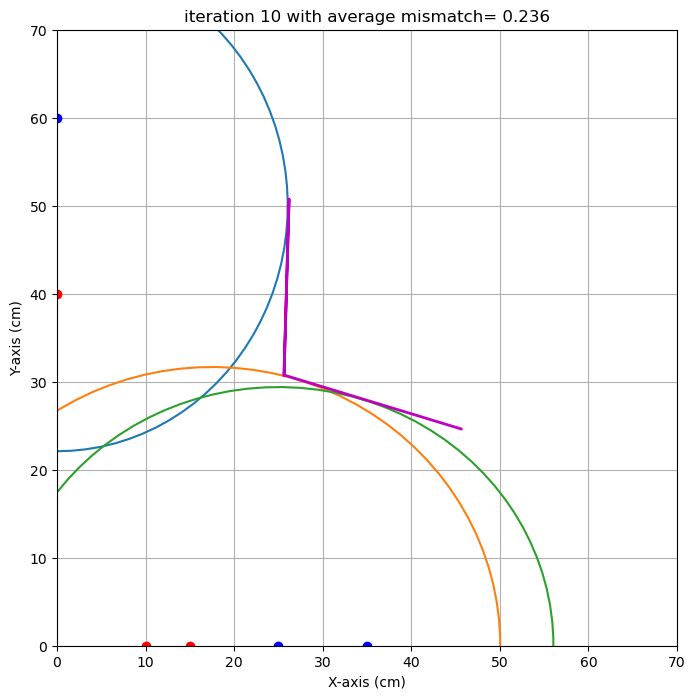

end iteration 10 with average mismatch= 0.236


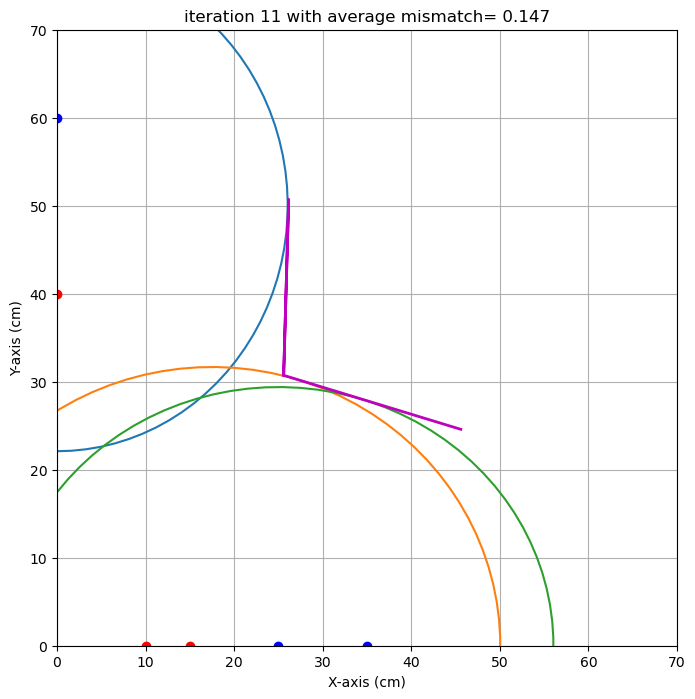

end iteration 11 with average mismatch= 0.147
end iteration 12 with average mismatch= 0.147
end iteration 13 with average mismatch= 0.146
end iteration 14 with average mismatch= 0.146
end iteration 15 with average mismatch= 0.146
end iteration 16 with average mismatch= 0.146
end iteration 17 with average mismatch= 0.146
end iteration 18 with average mismatch= 0.146
end iteration 19 with average mismatch= 0.146
end iteration 20 with average mismatch= 0.146
end iteration 21 with average mismatch= 0.146
end iteration 22 with average mismatch= 0.146
end iteration 23 with average mismatch= 0.146
end iteration 24 with average mismatch= 0.146
end iteration 25 with average mismatch= 0.146
end iteration 26 with average mismatch= 0.146
end iteration 27 with average mismatch= 0.146
end iteration 28 with average mismatch= 0.146
end iteration 29 with average mismatch= 0.146
Last iteration, also determine uncertainty, wait a while..
wait a little longer....
wait a little longer....
end iteration 30 

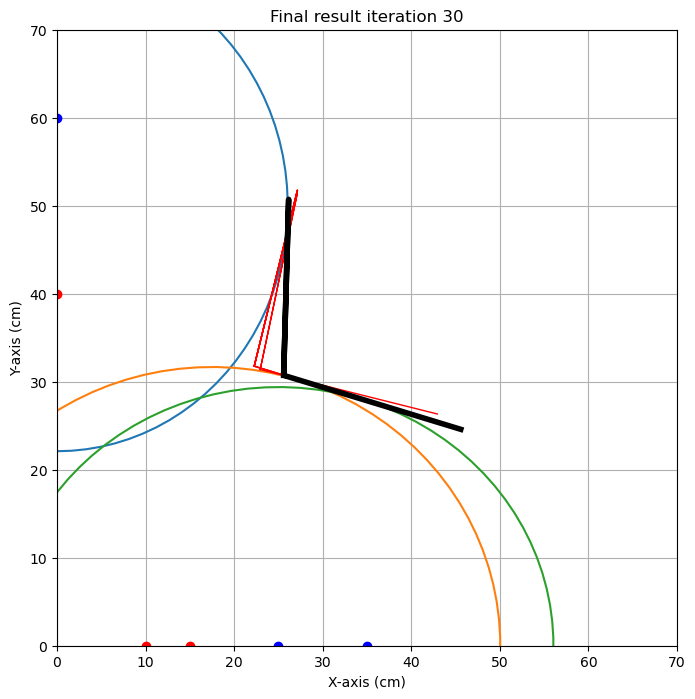

{'alpha': np.float64(-17.055707408146052), 'alpha_eps': np.float64(2.873427906388965), 'beta': np.float64(1.6193615213665884), 'beta_eps': np.float64(12.088459506321902), 'x0': np.float64(25.586304195970428), 'x0_eps': np.float64(3.322071065331947), 'y0': np.float64(30.725254200047303), 'y0_eps': np.float64(1.0432637481673446)}
Zul
Running the imaging algorithm with the following data:
   xs  ys  xr  yr     R
0   0  40   0  60  55.8
1  10   0  25   0  65.1
2  15   0  35   0  62.1


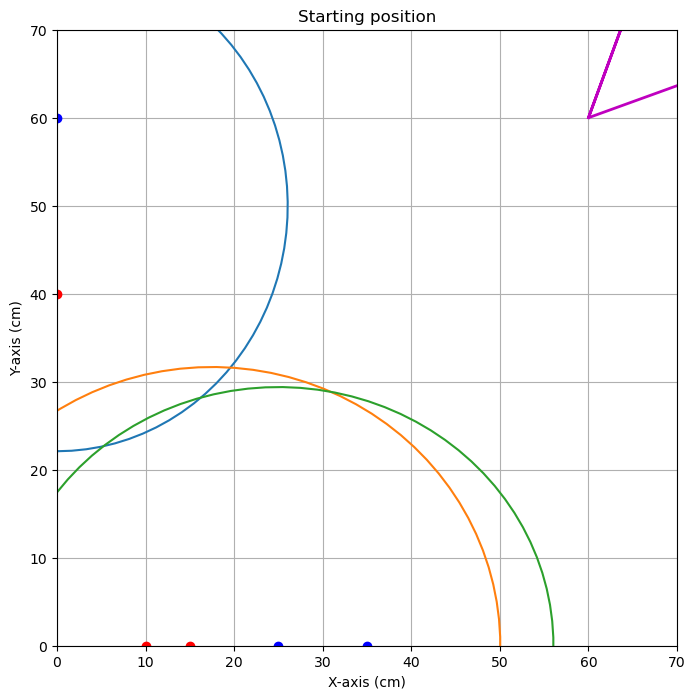


Wacht tot berekeningen klaar zijn; er komen  30 iteraties ...

end iteration 1 with average mismatch=82.642


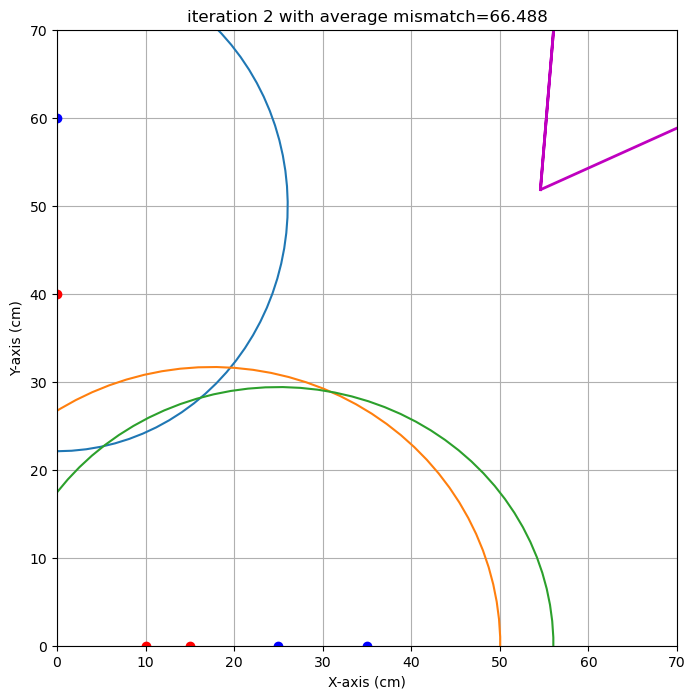

end iteration 2 with average mismatch=66.488


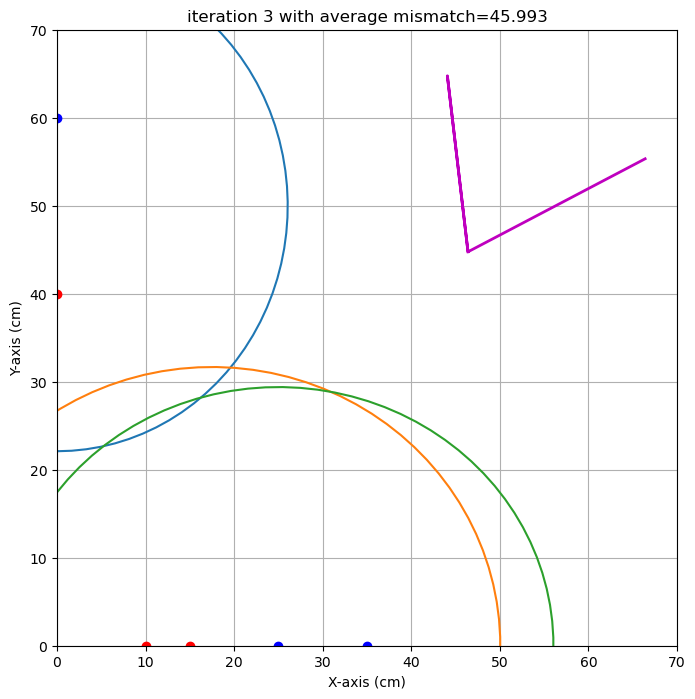

end iteration 3 with average mismatch=45.993


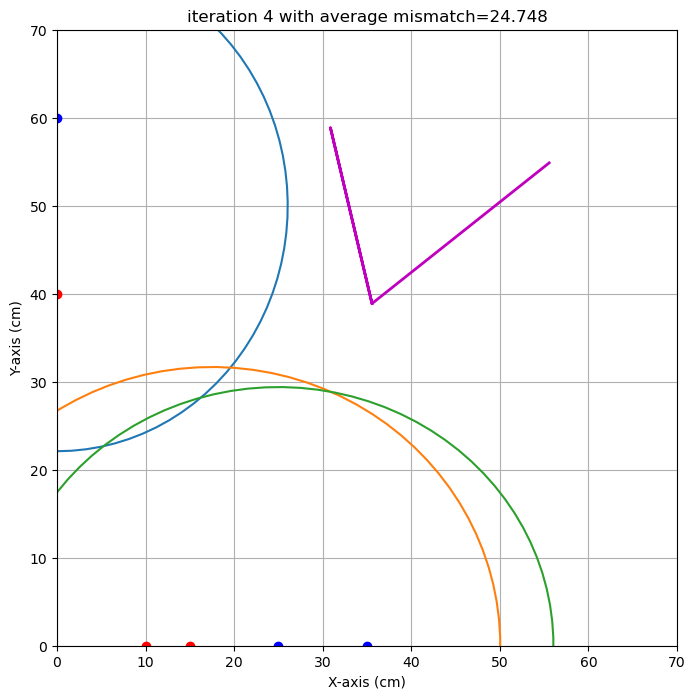

end iteration 4 with average mismatch=24.748


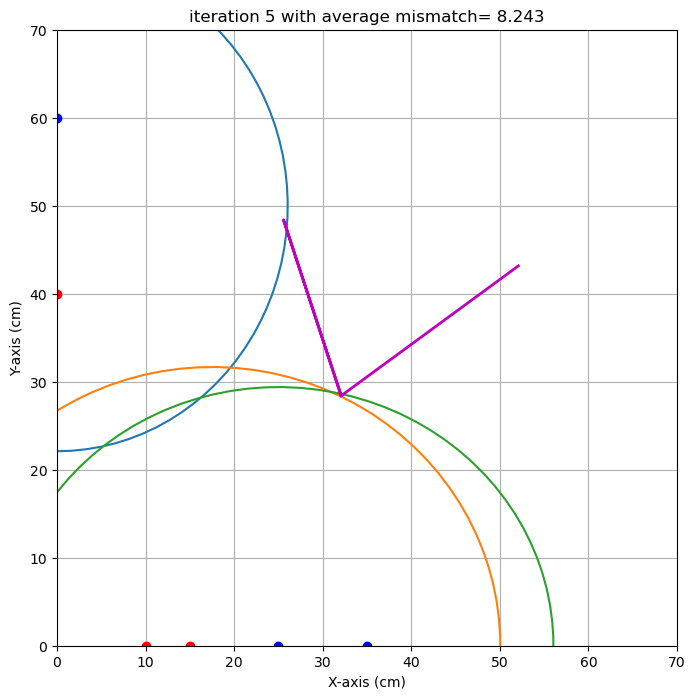

end iteration 5 with average mismatch= 8.243
end iteration 6 with average mismatch= 8.243
end iteration 7 with average mismatch= 8.229


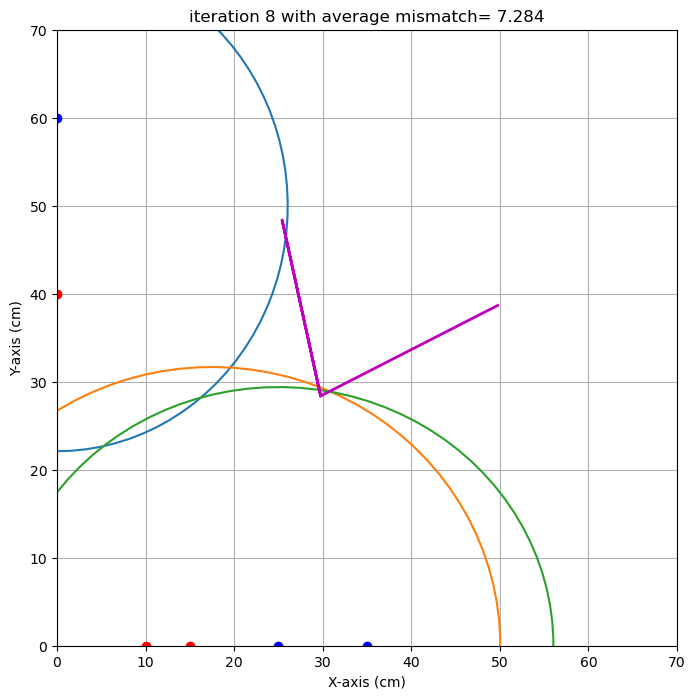

end iteration 8 with average mismatch= 7.284


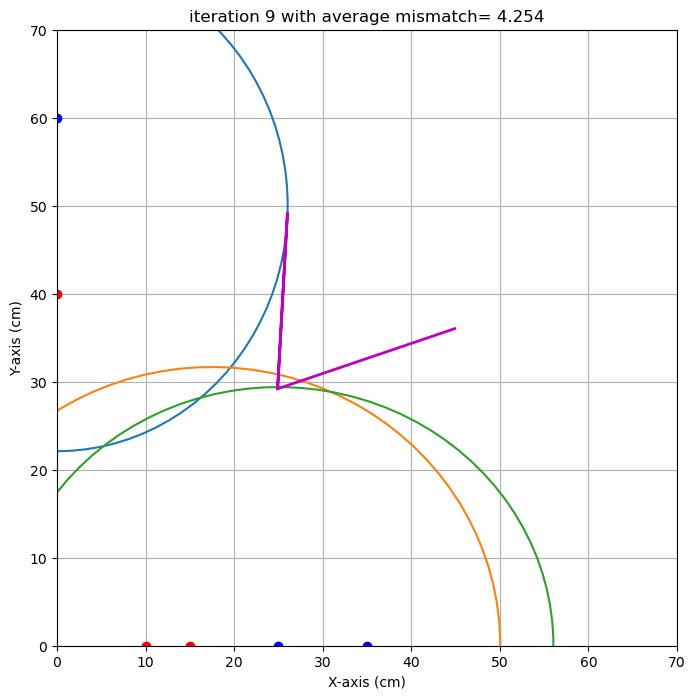

end iteration 9 with average mismatch= 4.254


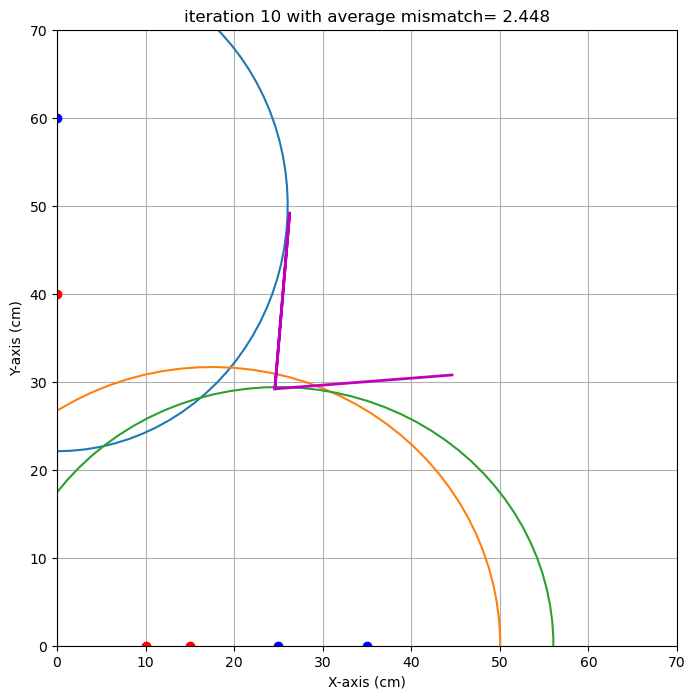

end iteration 10 with average mismatch= 2.448


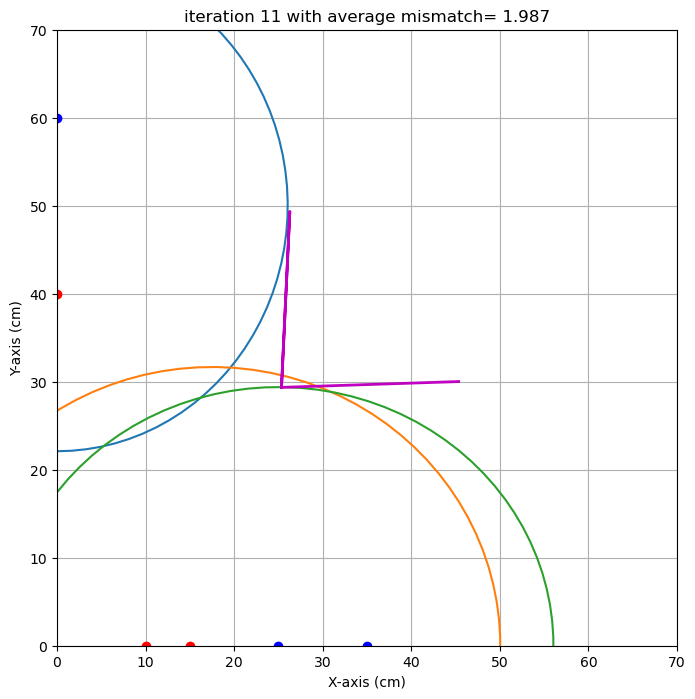

end iteration 11 with average mismatch= 1.987


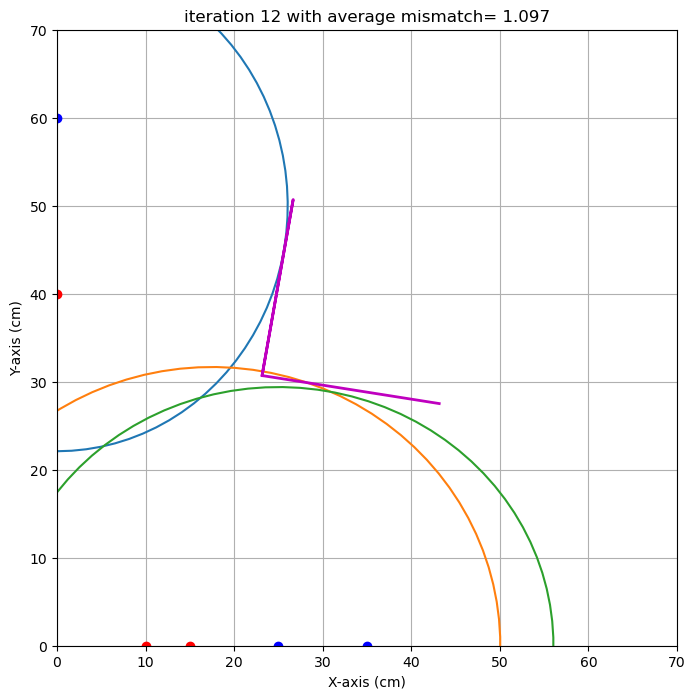

end iteration 12 with average mismatch= 1.097


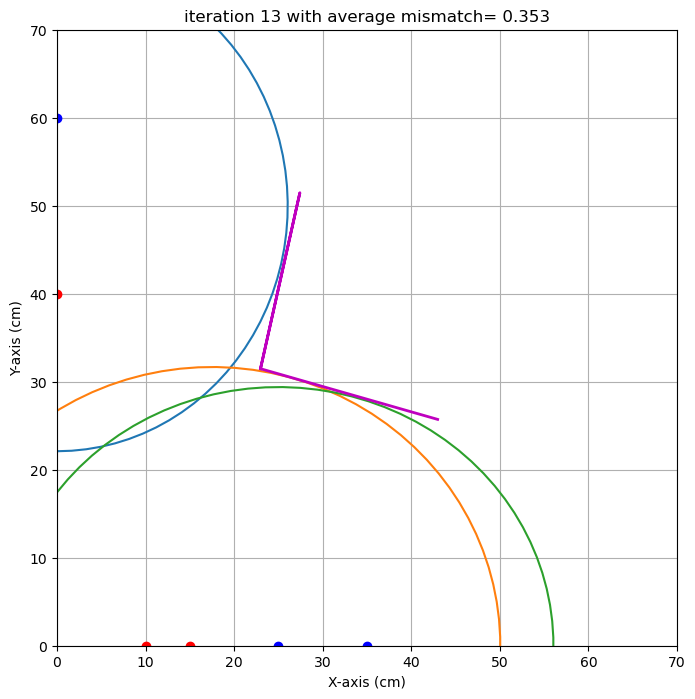

end iteration 13 with average mismatch= 0.353


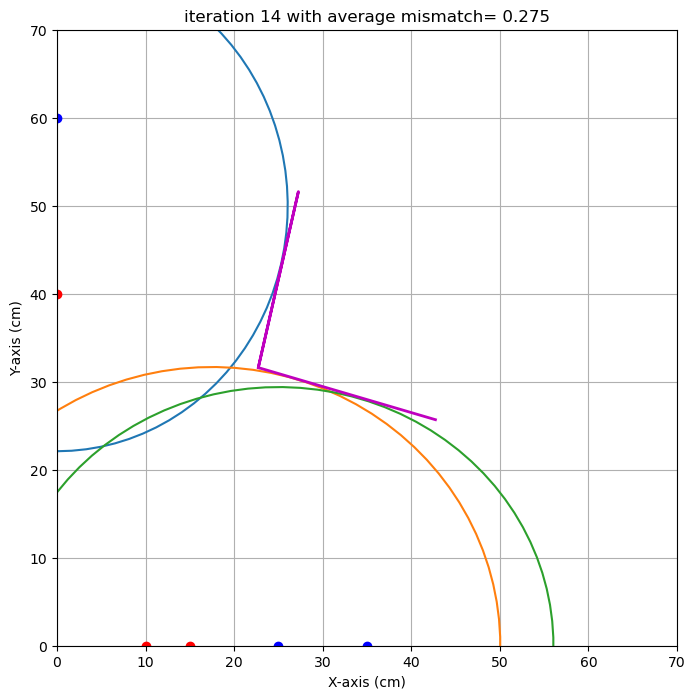

end iteration 14 with average mismatch= 0.275


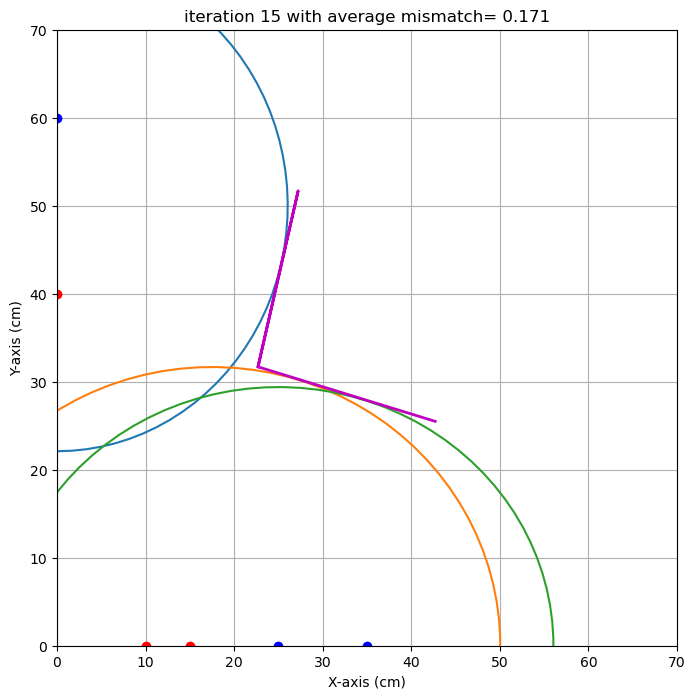

end iteration 15 with average mismatch= 0.171


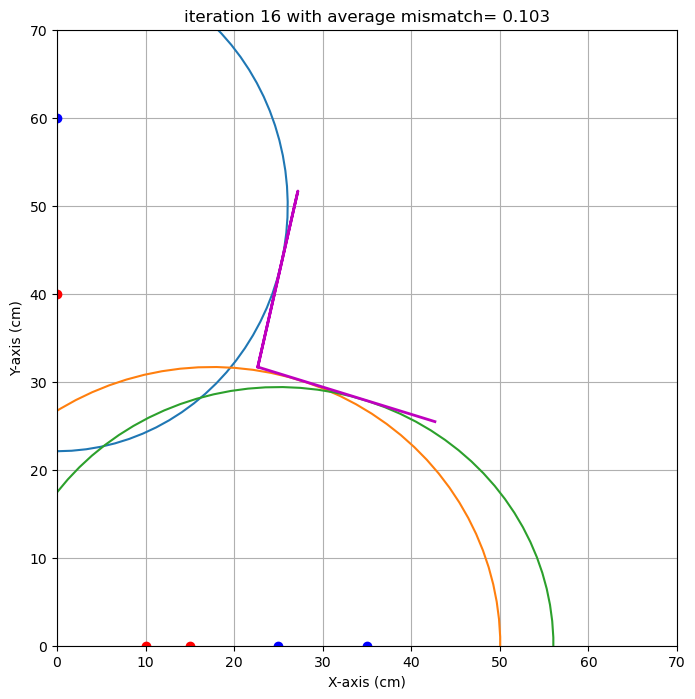

end iteration 16 with average mismatch= 0.103


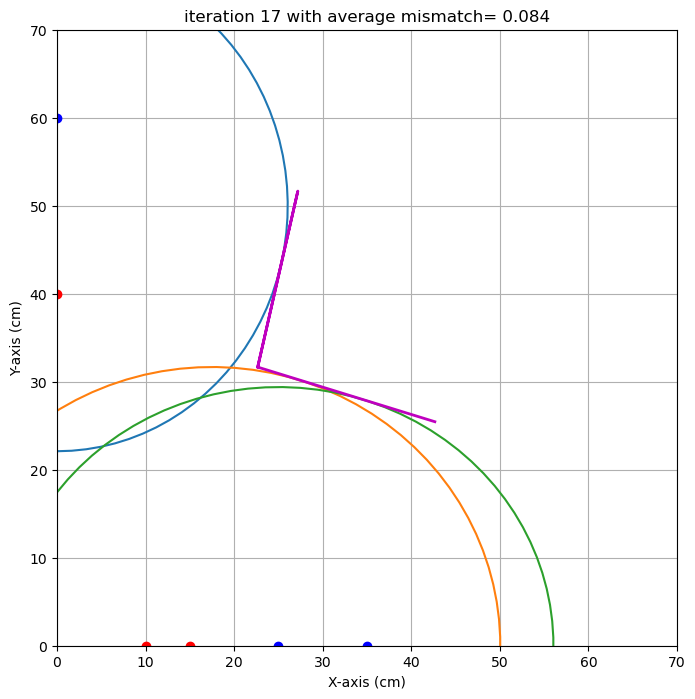

end iteration 17 with average mismatch= 0.084
end iteration 18 with average mismatch= 0.082
end iteration 19 with average mismatch= 0.081
end iteration 20 with average mismatch= 0.081
end iteration 21 with average mismatch= 0.081
end iteration 22 with average mismatch= 0.081
end iteration 23 with average mismatch= 0.081
end iteration 24 with average mismatch= 0.081
end iteration 25 with average mismatch= 0.081
end iteration 26 with average mismatch= 0.081
end iteration 27 with average mismatch= 0.081
end iteration 28 with average mismatch= 0.081
end iteration 29 with average mismatch= 0.081
Last iteration, also determine uncertainty, wait a while..
wait a little longer....
wait a little longer....
end iteration 30 with average mismatch= 0.081
###############################################################################
end of iteration  30
Best alpha= -17.24 with uncertainty=   1.87
Best beta =  12.76 with uncertainty=   7.43
Best x0   =  22.65 with uncertainty=   1.87
Best y0   =  3

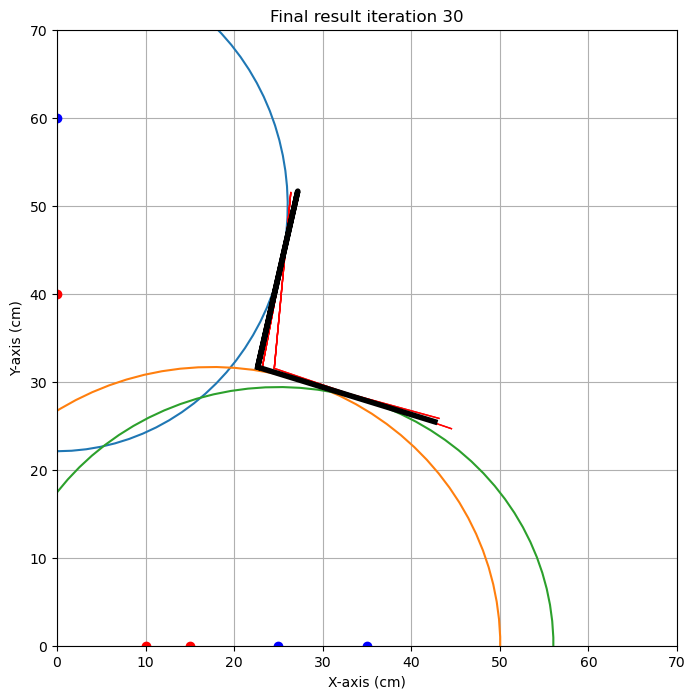

{'alpha': np.float64(-17.242017484354893), 'alpha_eps': np.float64(1.8663564500622911), 'beta': np.float64(12.758955810752388), 'beta_eps': np.float64(7.426001135710809), 'x0': np.float64(22.652602273946815), 'x0_eps': np.float64(1.874439054983089), 'y0': np.float64(31.654790387061304), 'y0_eps': np.float64(0.318043741422283)}


In [8]:
# Hier runnen we het imaging algoritme:
resultaat = dict()

for studentName in studentNames:
    print(studentName)
    resultaat[studentName] = imagingDEF.imagingDEF(data['Lieke'])
    print(resultaat[studentName])

In [9]:
# Run deze cel om jullie resultaten naast elkaar te kunnen zien.
for studentName in studentNames:
    txt='{naam} \r\nx0 target is : {x0Target:.1f}. Gevonden waarde: {x0:.1f} cm met een standaardafwijking van {x0_eps:.1f} cm \r\n'
    txt = txt + 'y0 target is : {y0Target:.1f}. Gevonden waarde: {y0:.1f} cm met een standaardafwijking van {y0_eps:.1f} cm \r\n'
    txt = txt + 'alpha target is : {alphaTarget:.1f}. Gevonden waarde: {alpha:.1f} graden met een standaardafwijking van {alpha_eps:.1f} graad \r\n'
    txt = txt + 'beta target is : {betaTarget:.1f}. Gevonden waarde: {beta:.1f} graden met een standaardafwijking van {beta_eps:.1f} graad \r\n'
    print(txt.format(naam = studentName,
                     x0Target=targets['x0'],
                     x0=resultaat[studentName]['x0'],
                     x0_eps=resultaat[studentName]['x0_eps'],
                     y0Target=targets['y0'],
                     y0=resultaat[studentName]['y0'],
                     y0_eps=resultaat[studentName]['y0_eps'],
                     alphaTarget=targets['alpha'],
                     alpha=resultaat[studentName]['alpha'],
                     alpha_eps=resultaat[studentName]['alpha_eps'],
                     betaTarget=targets['beta'],
                     beta=resultaat[studentName]['beta'],
                     beta_eps=resultaat[studentName]['beta_eps']))

Lieke 
x0 target is : 23.0. Gevonden waarde: 22.7 cm met een standaardafwijking van 2.6 cm 
y0 target is : 45.0. Gevonden waarde: 32.0 cm met een standaardafwijking van 0.7 cm 
alpha target is : -20.0. Gevonden waarde: -18.6 graden met een standaardafwijking van 5.6 graad 
beta target is : 45.0. Gevonden waarde: 12.9 graden met een standaardafwijking van 13.8 graad 

Yu He 
x0 target is : 23.0. Gevonden waarde: 25.6 cm met een standaardafwijking van 3.3 cm 
y0 target is : 45.0. Gevonden waarde: 30.7 cm met een standaardafwijking van 1.0 cm 
alpha target is : -20.0. Gevonden waarde: -17.1 graden met een standaardafwijking van 2.9 graad 
beta target is : 45.0. Gevonden waarde: 1.6 graden met een standaardafwijking van 12.1 graad 

Zul 
x0 target is : 23.0. Gevonden waarde: 22.7 cm met een standaardafwijking van 1.9 cm 
y0 target is : 45.0. Gevonden waarde: 31.7 cm met een standaardafwijking van 0.3 cm 
alpha target is : -20.0. Gevonden waarde: -17.2 graden met een standaardafwijking van 

## Opdracht 8: Iteratie1+ 1600
### Synthese
Maak een nieuwe blokkenschema op A3 van wat je nu als algoritme gaat proberen. Als het kleine wijzigingen zijn ten opzichte van een vorige iteratie, kras dan gewoon in de oude blokkenschema als dat duidelijk blijft. Maak een foto en zet die hieronder. Zorg dat het iteratienummer goed op de foto te zien is.

Figuur: ![Alt](Itteratie2blokschema.jpg)

Dit is het uiteindelijke algoritme deze hebben we tijdens het meten aangepast door meer meetpuinten toe te voegen omdat we merkten dat er n iet genoeg waren. Die hebben we meteen bij hetzelfde schema gezet.

In [10]:
# Voeg hier eventueel (nieuwe) code toe die je nodig hebt om je algoritme uit te voeren. Dit is optioneel!

## Opdracht 9: Iteratie 1+ meeting en test

locatie 1
Running the imaging algorithm with the following data:
    xs  ys  xr  yr      R
0    0  40  40   0   55.2
1    0  40   0  60   33.7
2    0  30   0  60   37.1
3    0  35   0  50   26.3
4    0  50   0  60  125.7
5   10   0  25   0   36.2
6   15   0  35   0   37.3
7   15   0  20   0   34.2
8   10   0  40   0   41.5
9   50   0  20   0   40.6
10   0  25   0  50   33.7


c:\Users\lieke\miniconda3\Lib\site-packages\pandas\core\arraylike.py:399: RuntimeWarning: invalid value encountered in sqrt
  result = getattr(ufunc, method)(*inputs, **kwargs)


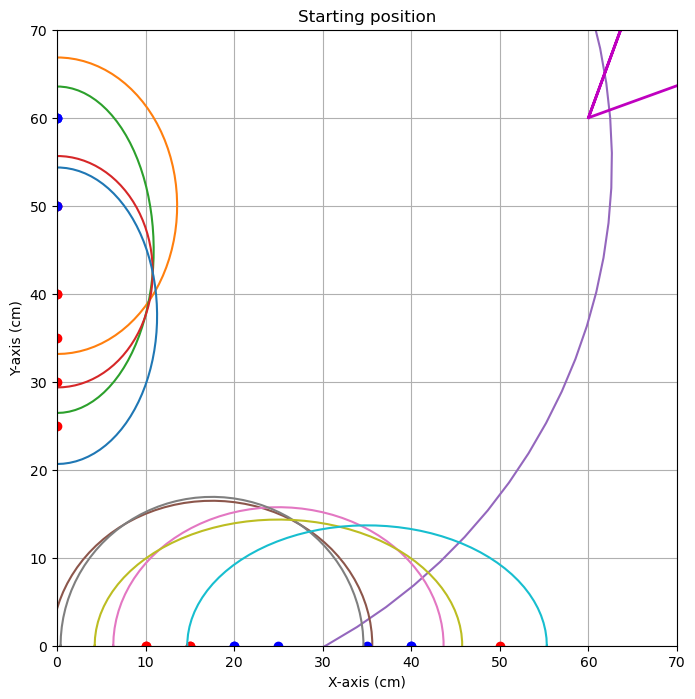


Wacht tot berekeningen klaar zijn; er komen  30 iteraties ...

end iteration 1 with average mismatch=94.877
end iteration 2 with average mismatch=88.955


c:\Users\lieke\miniconda3\Lib\site-packages\pandas\core\arraylike.py:399: RuntimeWarning: invalid value encountered in sqrt
  result = getattr(ufunc, method)(*inputs, **kwargs)


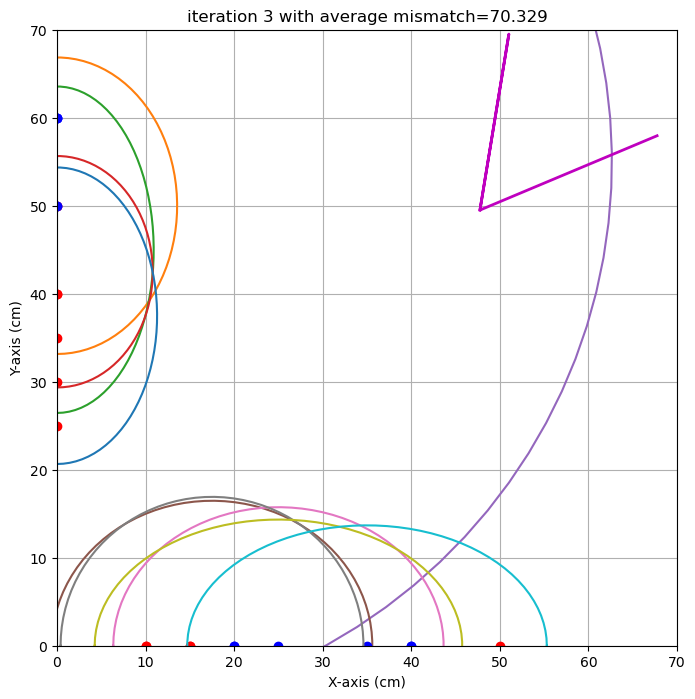

end iteration 3 with average mismatch=70.329


c:\Users\lieke\miniconda3\Lib\site-packages\pandas\core\arraylike.py:399: RuntimeWarning: invalid value encountered in sqrt
  result = getattr(ufunc, method)(*inputs, **kwargs)


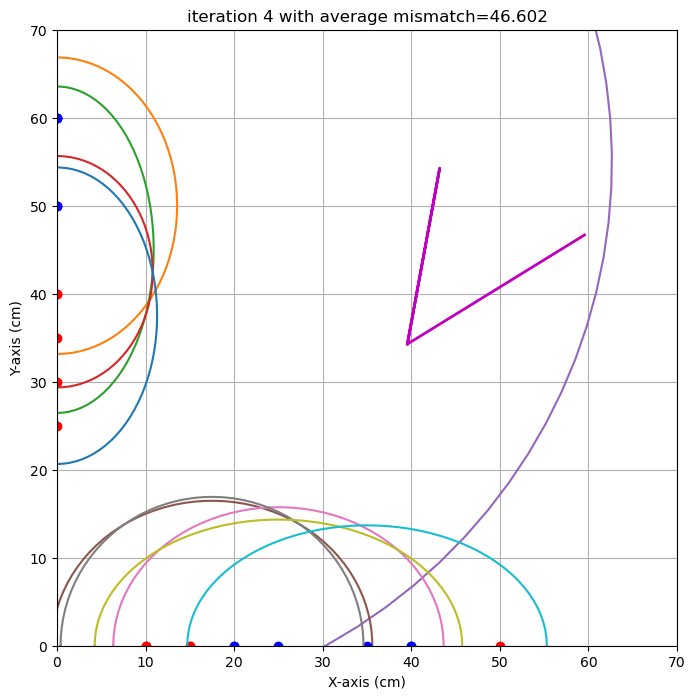

end iteration 4 with average mismatch=46.602


c:\Users\lieke\miniconda3\Lib\site-packages\pandas\core\arraylike.py:399: RuntimeWarning: invalid value encountered in sqrt
  result = getattr(ufunc, method)(*inputs, **kwargs)


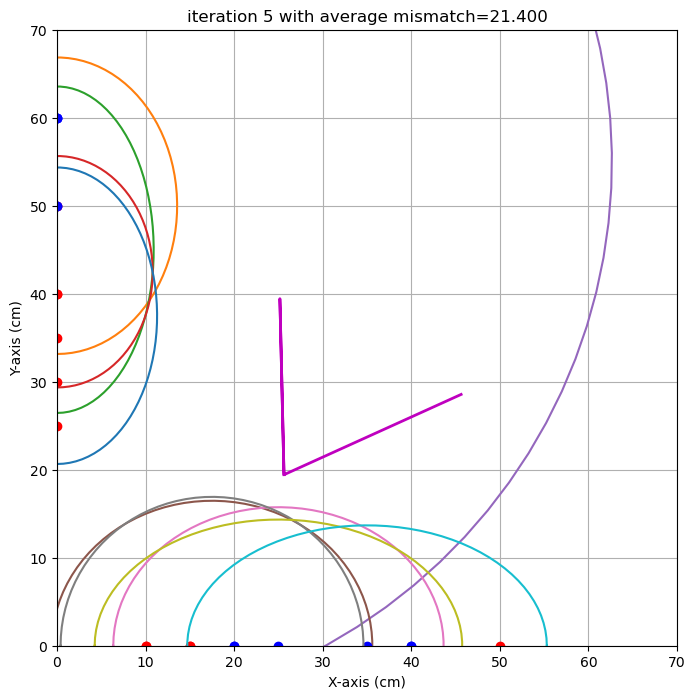

end iteration 5 with average mismatch=21.400


c:\Users\lieke\miniconda3\Lib\site-packages\pandas\core\arraylike.py:399: RuntimeWarning: invalid value encountered in sqrt
  result = getattr(ufunc, method)(*inputs, **kwargs)


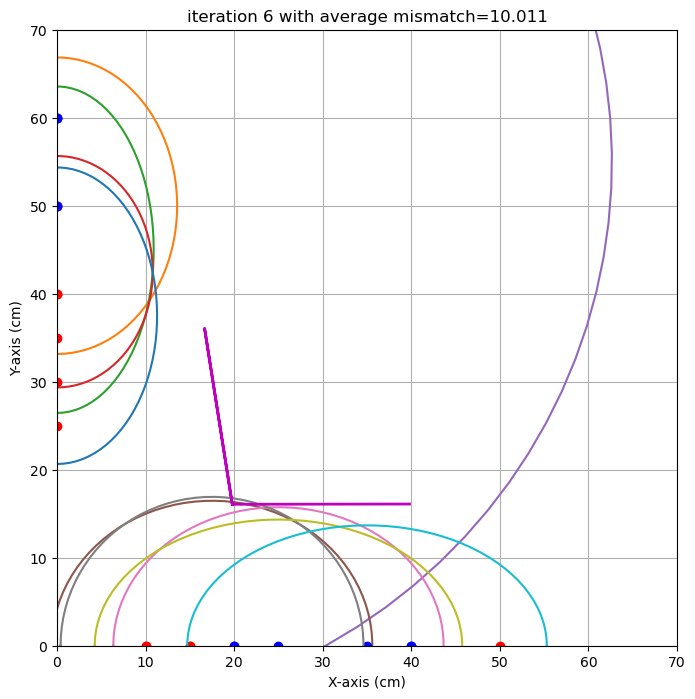

end iteration 6 with average mismatch=10.011


c:\Users\lieke\miniconda3\Lib\site-packages\pandas\core\arraylike.py:399: RuntimeWarning: invalid value encountered in sqrt
  result = getattr(ufunc, method)(*inputs, **kwargs)


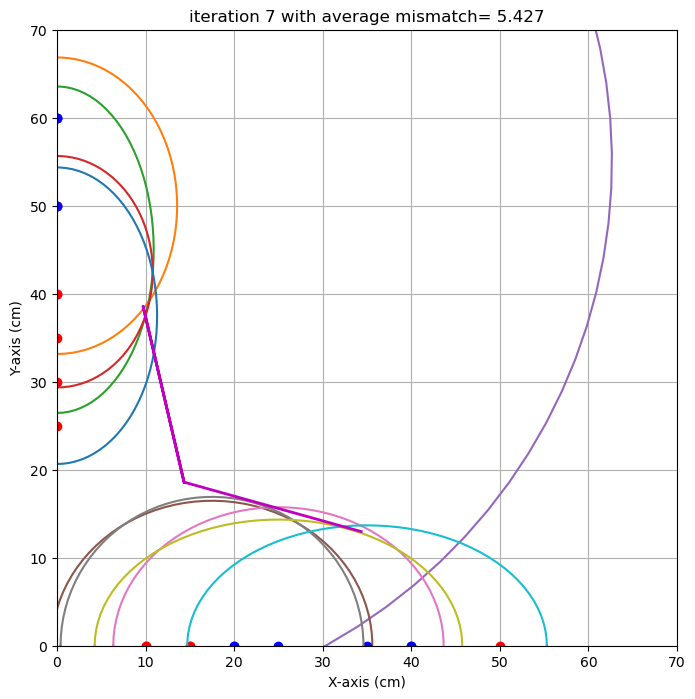

end iteration 7 with average mismatch= 5.427
end iteration 8 with average mismatch= 5.313
end iteration 9 with average mismatch= 5.230
end iteration 10 with average mismatch= 5.230
end iteration 11 with average mismatch= 5.230
end iteration 12 with average mismatch= 5.230
end iteration 13 with average mismatch= 5.230
end iteration 14 with average mismatch= 5.230
end iteration 15 with average mismatch= 5.230
end iteration 16 with average mismatch= 5.230
end iteration 17 with average mismatch= 5.227
end iteration 18 with average mismatch= 5.227
end iteration 19 with average mismatch= 5.227
end iteration 20 with average mismatch= 5.227
end iteration 21 with average mismatch= 5.227
end iteration 22 with average mismatch= 5.227
end iteration 23 with average mismatch= 5.210
end iteration 24 with average mismatch= 5.210
end iteration 25 with average mismatch= 5.204
end iteration 26 with average mismatch= 5.204
end iteration 27 with average mismatch= 5.204
end iteration 28 with average mismatc

c:\Users\lieke\miniconda3\Lib\site-packages\pandas\core\arraylike.py:399: RuntimeWarning: invalid value encountered in sqrt
  result = getattr(ufunc, method)(*inputs, **kwargs)


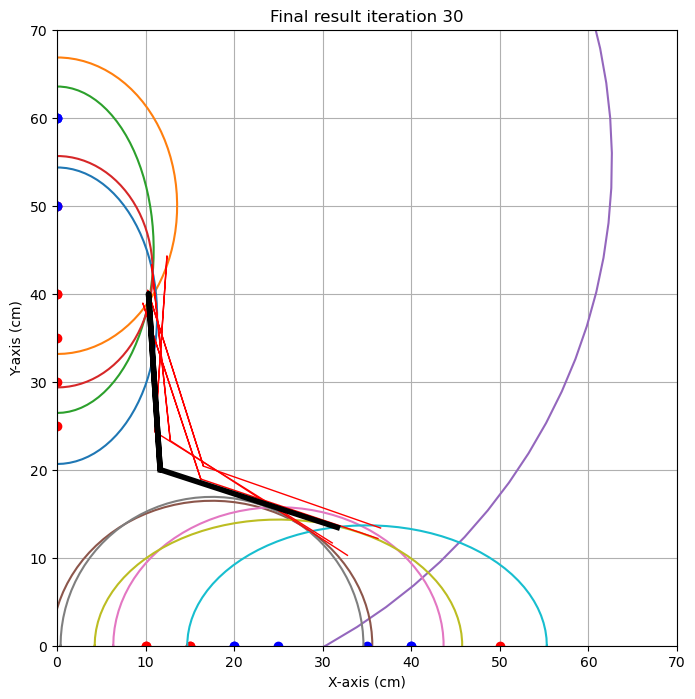

{'alpha': np.float64(-18.15776356258164), 'alpha_eps': np.float64(14.927165597090461), 'beta': np.float64(-3.7537258657096233), 'beta_eps': np.float64(14.359143300445705), 'x0': np.float64(11.642924159909713), 'x0_eps': np.float64(4.885499427609153), 'y0': np.float64(20.008724275794695), 'y0_eps': np.float64(4.289452439869411)}
locatie 2
Running the imaging algorithm with the following data:
   xs  ys  xr  yr     R
0   0  40  40   0  56.3
1   0  15   0  35  33.5
2   0  10   0  25  32.4
3  15   0  35   0  33.2
4  10   0  25   0  33.6
5   0   0   0  50  52.0
6   0   0  50   0  63.4
7   0  10   0  40  38.0
8  10   0  40   0  39.6
9  15   0  20   0  29.2


c:\Users\lieke\miniconda3\Lib\site-packages\pandas\core\arraylike.py:399: RuntimeWarning: invalid value encountered in sqrt
  result = getattr(ufunc, method)(*inputs, **kwargs)


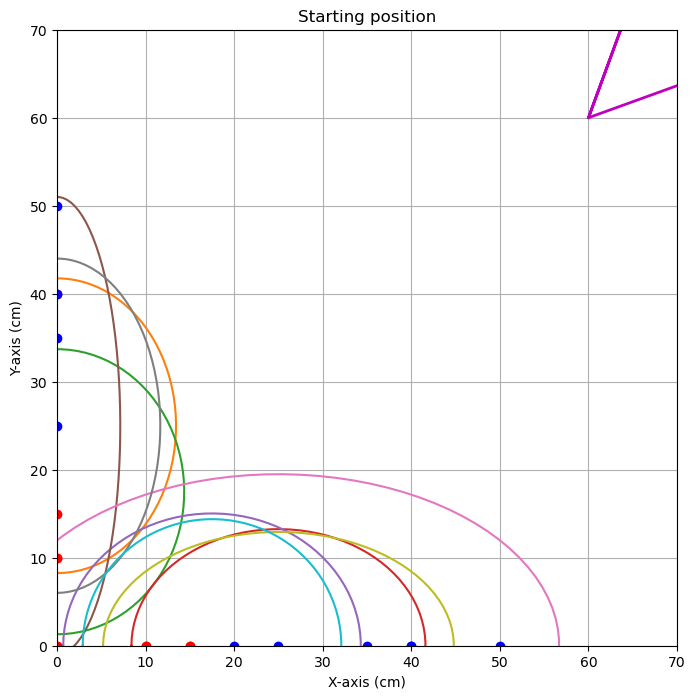


Wacht tot berekeningen klaar zijn; er komen  30 iteraties ...

end iteration 1 with average mismatch=108.463


c:\Users\lieke\miniconda3\Lib\site-packages\pandas\core\arraylike.py:399: RuntimeWarning: invalid value encountered in sqrt
  result = getattr(ufunc, method)(*inputs, **kwargs)


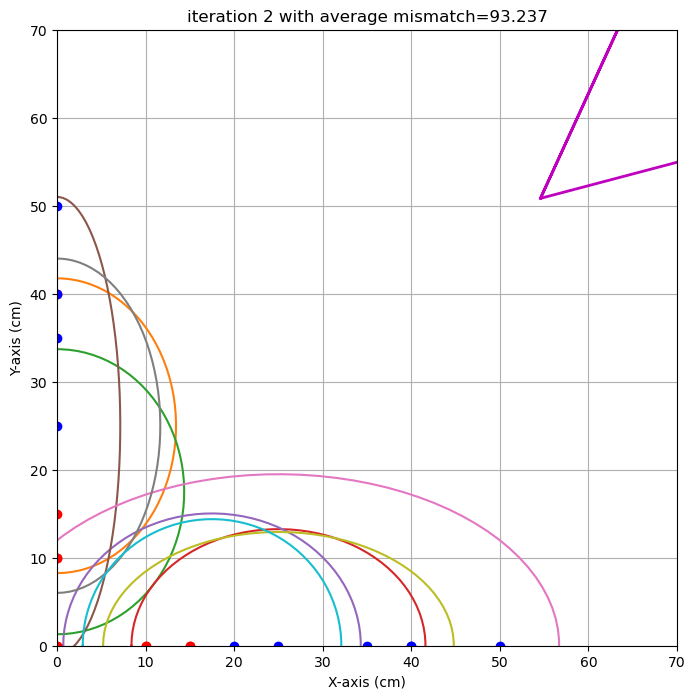

end iteration 2 with average mismatch=93.237


c:\Users\lieke\miniconda3\Lib\site-packages\pandas\core\arraylike.py:399: RuntimeWarning: invalid value encountered in sqrt
  result = getattr(ufunc, method)(*inputs, **kwargs)


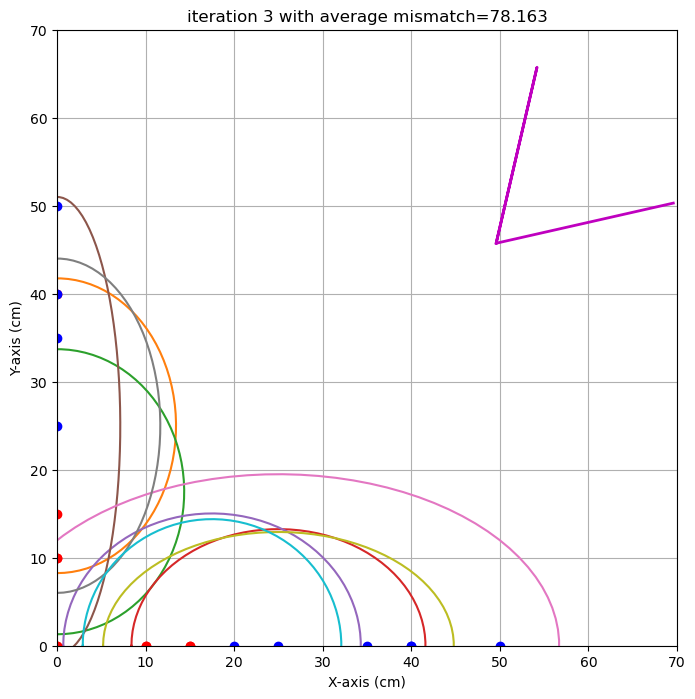

end iteration 3 with average mismatch=78.163


c:\Users\lieke\miniconda3\Lib\site-packages\pandas\core\arraylike.py:399: RuntimeWarning: invalid value encountered in sqrt
  result = getattr(ufunc, method)(*inputs, **kwargs)


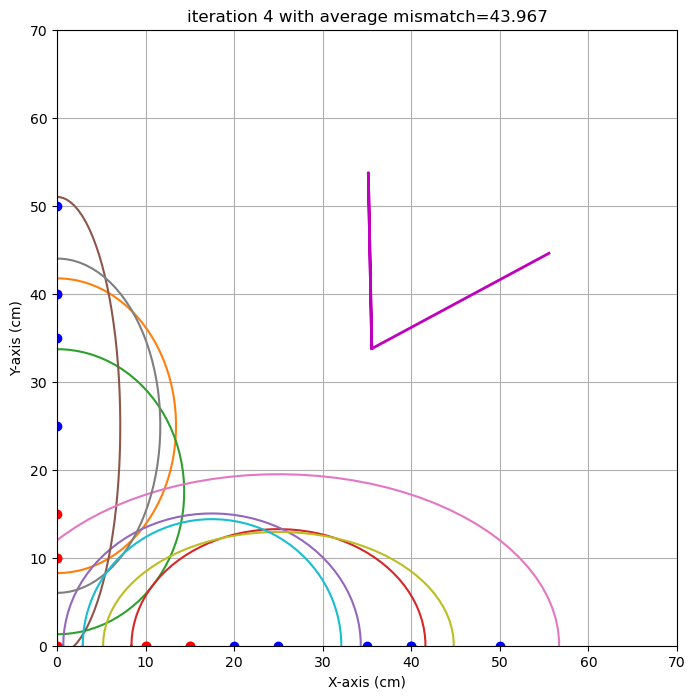

end iteration 4 with average mismatch=43.967


c:\Users\lieke\miniconda3\Lib\site-packages\pandas\core\arraylike.py:399: RuntimeWarning: invalid value encountered in sqrt
  result = getattr(ufunc, method)(*inputs, **kwargs)


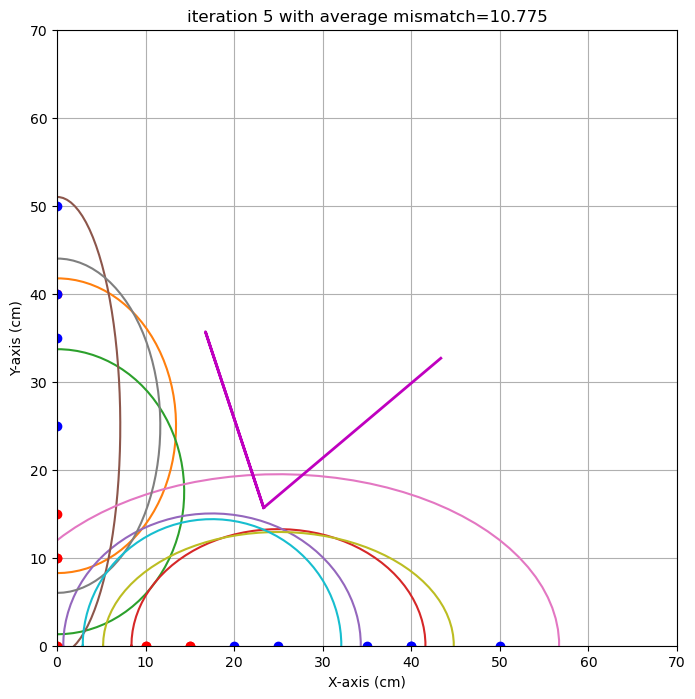

end iteration 5 with average mismatch=10.775


c:\Users\lieke\miniconda3\Lib\site-packages\pandas\core\arraylike.py:399: RuntimeWarning: invalid value encountered in sqrt
  result = getattr(ufunc, method)(*inputs, **kwargs)


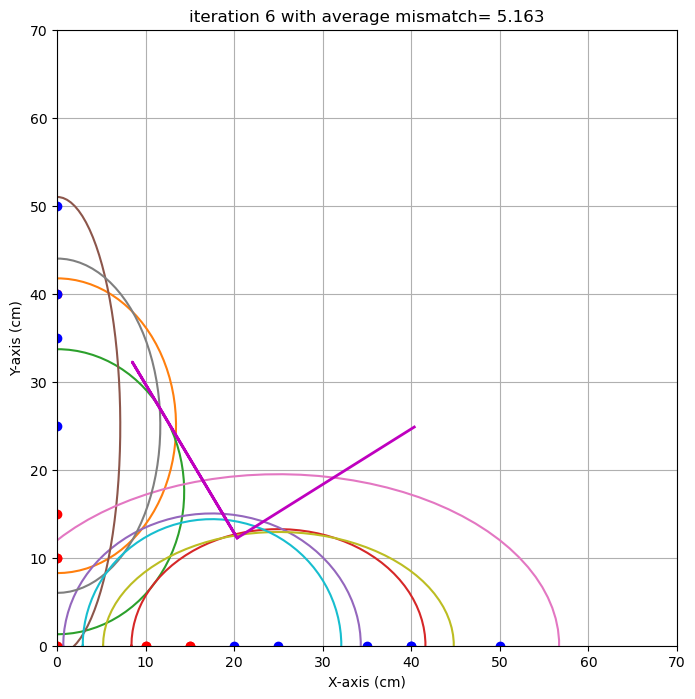

end iteration 6 with average mismatch= 5.163
end iteration 7 with average mismatch= 5.044


c:\Users\lieke\miniconda3\Lib\site-packages\pandas\core\arraylike.py:399: RuntimeWarning: invalid value encountered in sqrt
  result = getattr(ufunc, method)(*inputs, **kwargs)


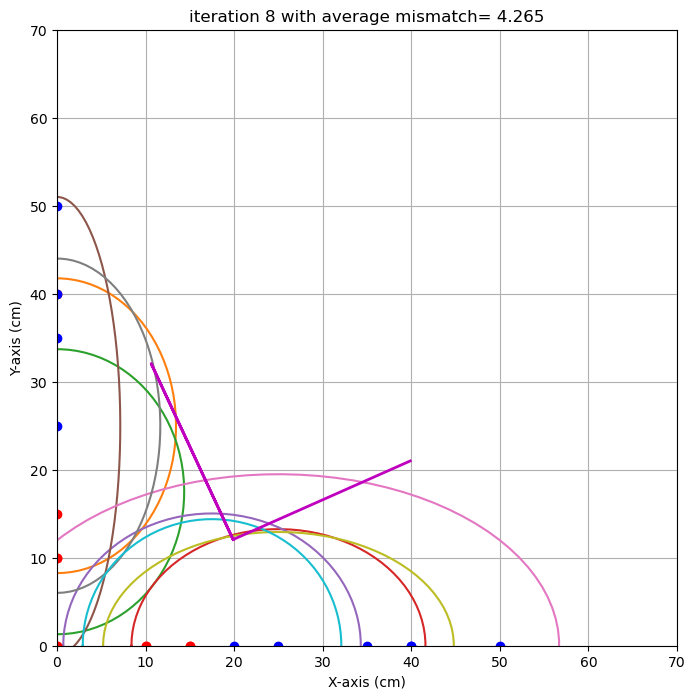

end iteration 8 with average mismatch= 4.265


c:\Users\lieke\miniconda3\Lib\site-packages\pandas\core\arraylike.py:399: RuntimeWarning: invalid value encountered in sqrt
  result = getattr(ufunc, method)(*inputs, **kwargs)


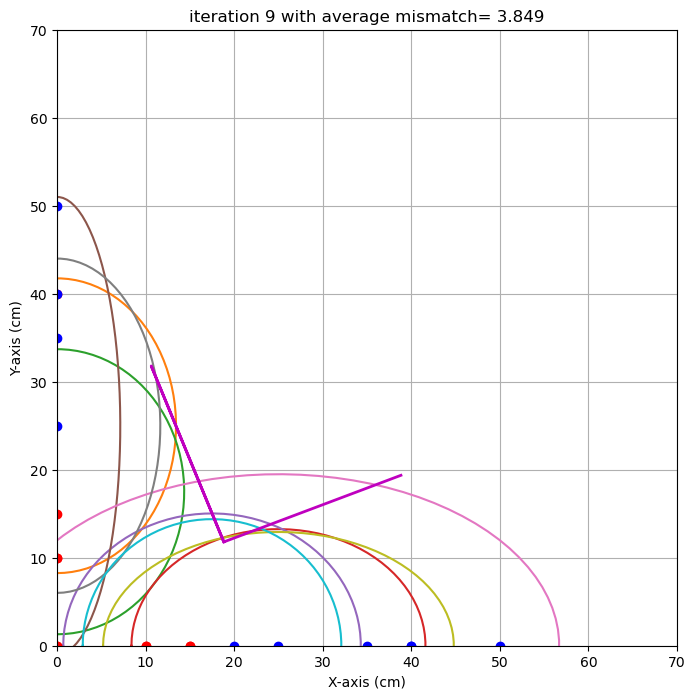

end iteration 9 with average mismatch= 3.849
end iteration 10 with average mismatch= 3.581
end iteration 11 with average mismatch= 3.511
end iteration 12 with average mismatch= 3.511
end iteration 13 with average mismatch= 3.378
end iteration 14 with average mismatch= 3.192
end iteration 15 with average mismatch= 3.192
end iteration 16 with average mismatch= 3.192
end iteration 17 with average mismatch= 3.192
end iteration 18 with average mismatch= 3.192
end iteration 19 with average mismatch= 3.192
end iteration 20 with average mismatch= 3.192
end iteration 21 with average mismatch= 3.192
end iteration 22 with average mismatch= 3.192
end iteration 23 with average mismatch= 3.192
end iteration 24 with average mismatch= 3.192
end iteration 25 with average mismatch= 3.192
end iteration 26 with average mismatch= 3.151


c:\Users\lieke\miniconda3\Lib\site-packages\pandas\core\arraylike.py:399: RuntimeWarning: invalid value encountered in sqrt
  result = getattr(ufunc, method)(*inputs, **kwargs)


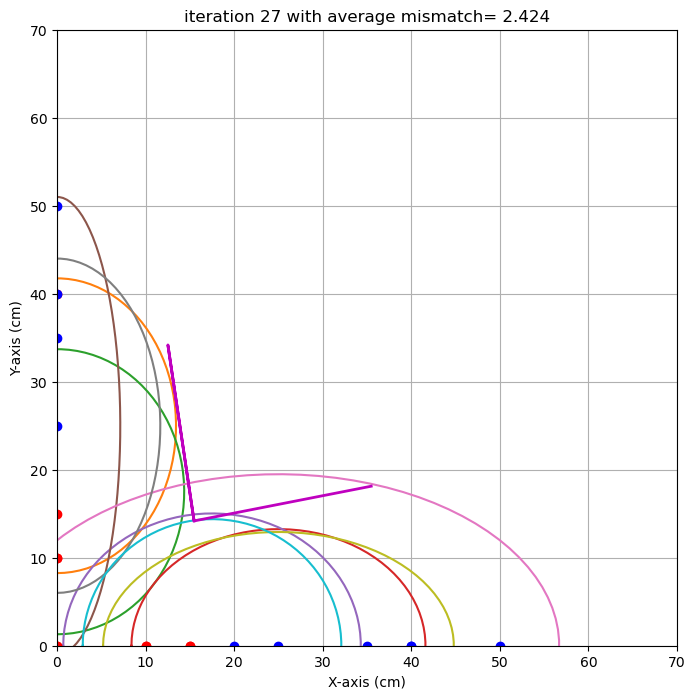

end iteration 27 with average mismatch= 2.424
end iteration 28 with average mismatch= 2.387
end iteration 29 with average mismatch= 2.300
Last iteration, also determine uncertainty, wait a while..
wait a little longer....
wait a little longer....
end iteration 30 with average mismatch= 2.300
###############################################################################
end of iteration  30
Best alpha=  11.98 with uncertainty=  14.99
Best beta =  -7.06 with uncertainty=  13.26
Best x0   =  14.92 with uncertainty=   3.35
Best y0   =  14.07 with uncertainty=   1.32
###############################################################################


c:\Users\lieke\miniconda3\Lib\site-packages\pandas\core\arraylike.py:399: RuntimeWarning: invalid value encountered in sqrt
  result = getattr(ufunc, method)(*inputs, **kwargs)


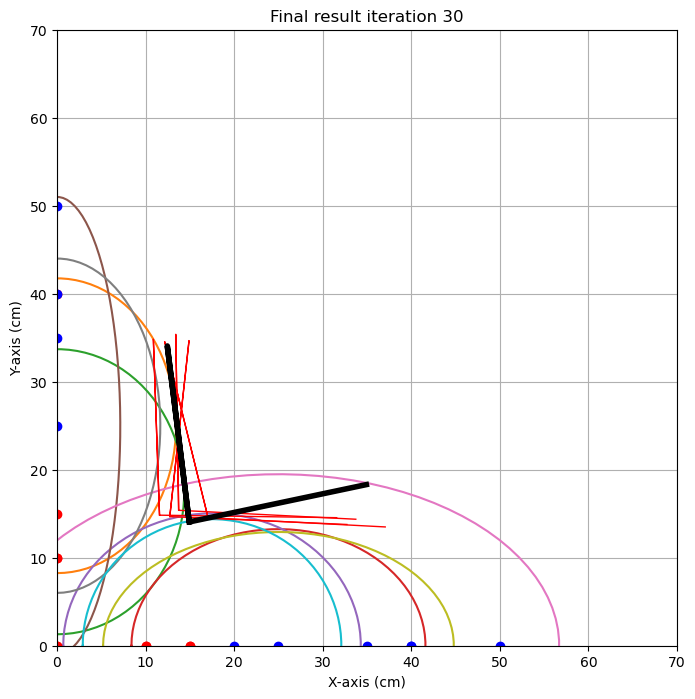

{'alpha': np.float64(11.976594748581364), 'alpha_eps': np.float64(14.990628641433794), 'beta': np.float64(-7.056597922872117), 'beta_eps': np.float64(13.256103327518169), 'x0': np.float64(14.923609644031421), 'x0_eps': np.float64(3.351679226738094), 'y0': np.float64(14.066331879860549), 'y0_eps': np.float64(1.3224525265202622)}
locatie 1 
x0 target is : 16.0. Gevonden waarde: 11.6 cm met een standaardafwijking van 4.9 cm 
y0 target is : 19.0. Gevonden waarde: 20.0 cm met een standaardafwijking van 4.3 cm 
alpha target is : -5.0. Gevonden waarde: -18.2 graden met een standaardafwijking van 14.9 graad 
beta target is : -10.0. Gevonden waarde: -3.8 graden met een standaardafwijking van 14.4 graad 

locatie 2 
x0 target is : 17.0. Gevonden waarde: 14.9 cm met een standaardafwijking van 3.4 cm 
y0 target is : 15.0. Gevonden waarde: 14.1 cm met een standaardafwijking van 1.3 cm 
alpha target is : 10.0. Gevonden waarde: 12.0 graden met een standaardafwijking van 15.0 graad 
beta target is : -

In [11]:
# Voeg hier je meetgegevens van deze iteratie in:

# Vul onderstaande in met jullie gekozen locaties van het reflecterende papier.
targets = {'locatie 1':{'x0': 16,
                    'y0': 19,
                    'alpha' : -5,
                    'beta' : -10,
                    },
           'locatie 2':{'x0': 17,
                    'y0': 15,
                    'alpha' : 10,
                    'beta' : -8,
                    }
            }
           

# Vul onderstaande matrixen aan met je gemeten meetgegevens.

data ={'locatie 1' :  pd.DataFrame(columns=["xs", "ys", "xr", "yr", "R"], data=[
    [0, 40, 40, 0, 55.2],
    [0,40,0,60,33.7],
    [0,30,0,60,37.1],
    [0,35,0,50,26.3],
    [0,50,0,60,125.7],
    [10,0,25,0, 36.2],
    [15,0,35,0, 37.3],
    [15,0,20,0,34.2],
    [10,0,40,0, 41.5],
    [50,0,20,0, 40.6],
    [0,25,0,50,33.7],
    ]),
       'locatie 2' : pd.DataFrame(columns=["xs", "ys", "xr", "yr", "R"], data=[
    [0,40,40,0,56.3],
    [0,15,0,35, 33.5],
    [0,10,0,25,32.4],
    [15,0,35,0,33.2],
    [10,0,25,0,33.6],
    [0,0,0,50,52.0],
    [0,0,50,0,63.4],
    [0,10,0,40, 38.0],
    [10,0,40,0,39.6],
    [15,0,20,0, 29.2],

    ])
      }
                        
                        
# Hier runnen we het imaging algoritme:
resultaat = dict()

for locatie in targets:
    print(locatie)
    resultaat[locatie] = imagingDEF.imagingDEF(data[locatie])
    print(resultaat[locatie])

                        
# en hier laten we de resultaten als text zien.
for locatie in targets:
    txt='{naam} \r\nx0 target is : {x0Target:.1f}. Gevonden waarde: {x0:.1f} cm met een standaardafwijking van {x0_eps:.1f} cm \r\n'
    txt = txt + 'y0 target is : {y0Target:.1f}. Gevonden waarde: {y0:.1f} cm met een standaardafwijking van {y0_eps:.1f} cm \r\n'
    txt = txt + 'alpha target is : {alphaTarget:.1f}. Gevonden waarde: {alpha:.1f} graden met een standaardafwijking van {alpha_eps:.1f} graad \r\n'
    txt = txt + 'beta target is : {betaTarget:.1f}. Gevonden waarde: {beta:.1f} graden met een standaardafwijking van {beta_eps:.1f} graad \r\n'
    print(txt.format(naam = locatie,
                     x0Target=targets[locatie]['x0'],
                     x0=resultaat[locatie]['x0'],
                     x0_eps=resultaat[locatie]['x0_eps'],
                     y0Target=targets[locatie]['y0'],
                     y0=resultaat[locatie]['y0'],
                     y0_eps=resultaat[locatie]['y0_eps'],
                     alphaTarget=targets[locatie]['alpha'],
                     alpha=resultaat[locatie]['alpha'],
                     alpha_eps=resultaat[locatie]['alpha_eps'],
                     betaTarget=targets[locatie]['beta'],
                     beta=resultaat[locatie]['beta'],
                     beta_eps=resultaat[locatie]['beta_eps']))
    

## Opdracht 10: Uiteindelijke test met locatie gegeven door TA

test locatie
Running the imaging algorithm with the following data:
   xs  ys  xr  yr     R
0   0  30   0  60  49.8
1   0  35   0  50  44.3
2  10   0  25   0  54.8
3  15   0  35   0  54.2
4  15   0  20   0  54.7
5  10   0  40   0  57.7
6   0  10   0  60  58.6


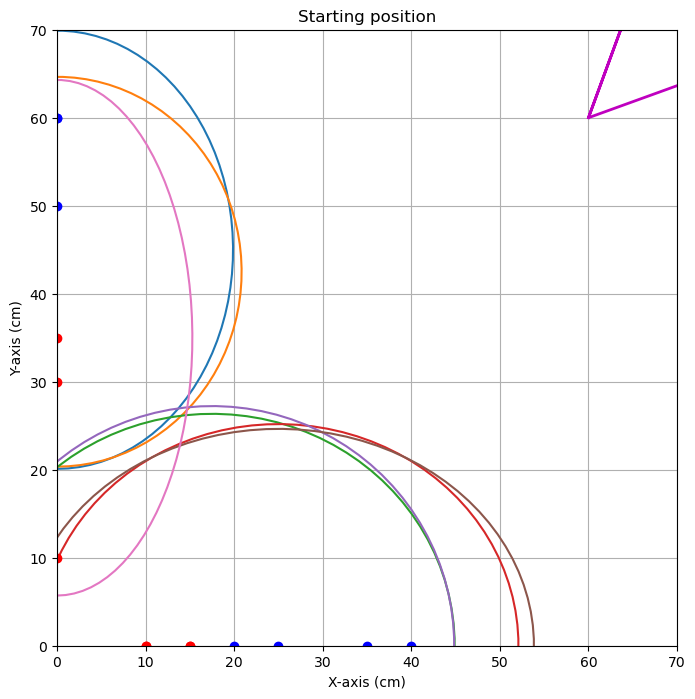


Wacht tot berekeningen klaar zijn; er komen  30 iteraties ...

end iteration 1 with average mismatch=91.295


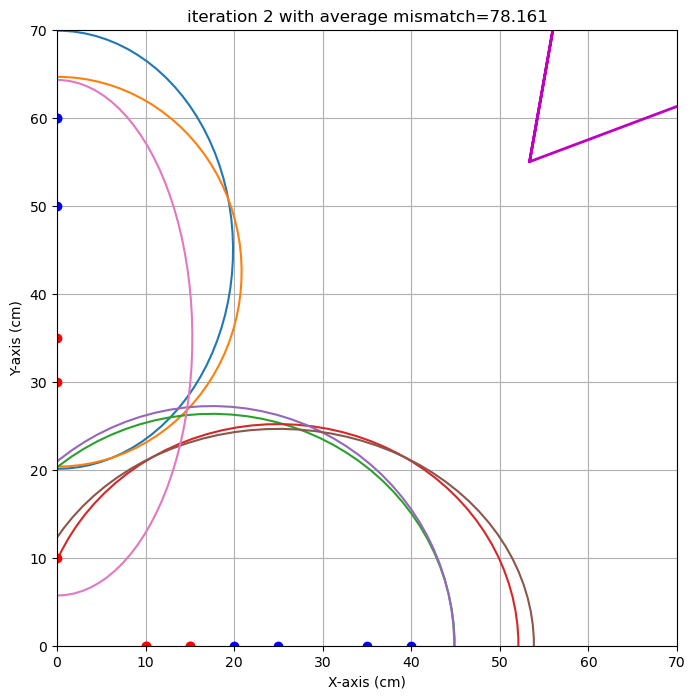

end iteration 2 with average mismatch=78.161


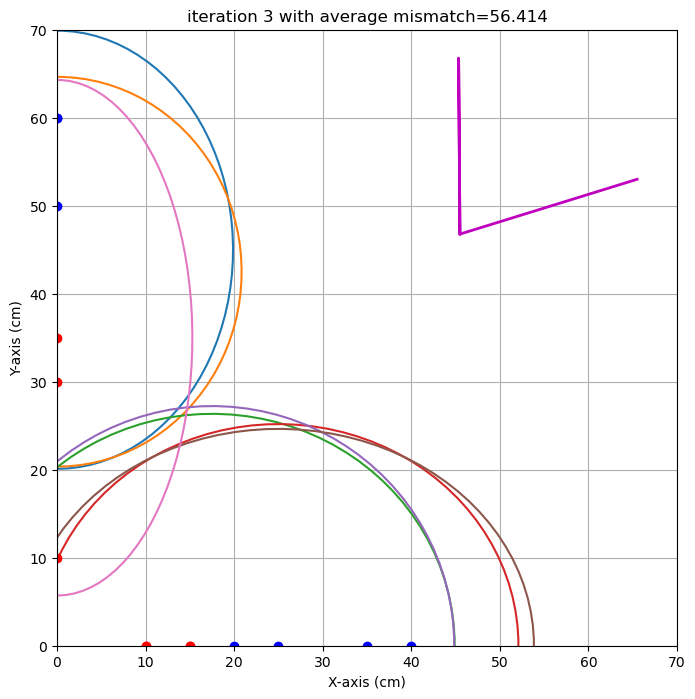

end iteration 3 with average mismatch=56.414


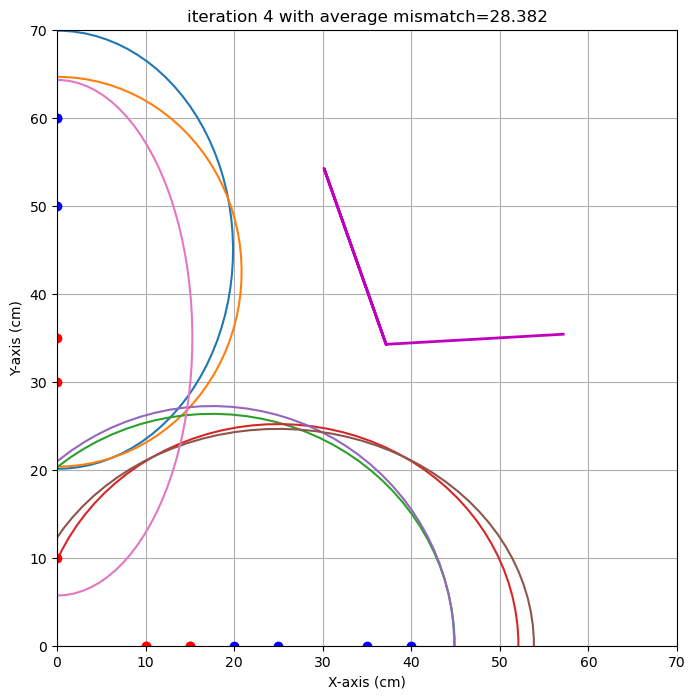

end iteration 4 with average mismatch=28.382


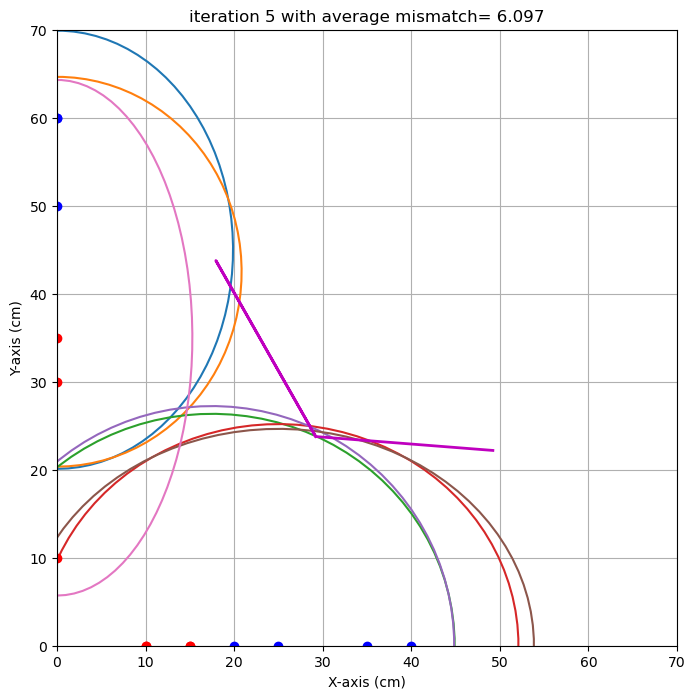

end iteration 5 with average mismatch= 6.097


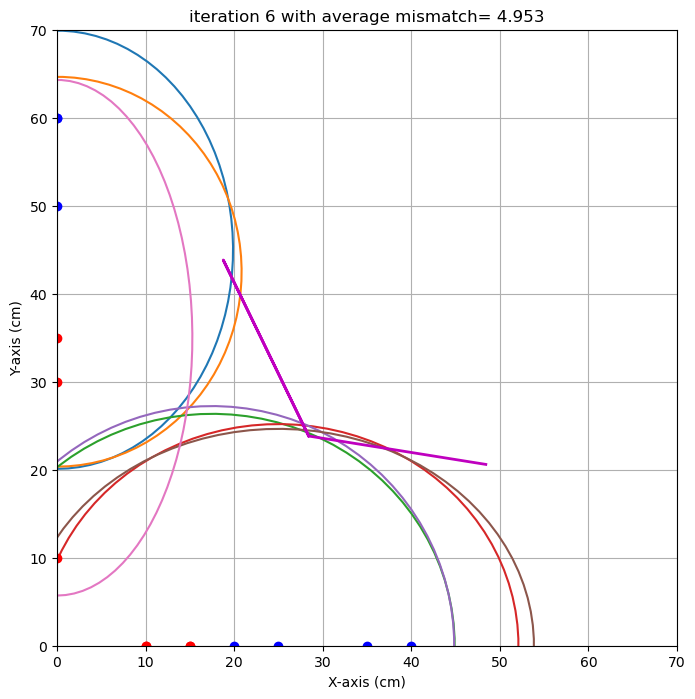

end iteration 6 with average mismatch= 4.953


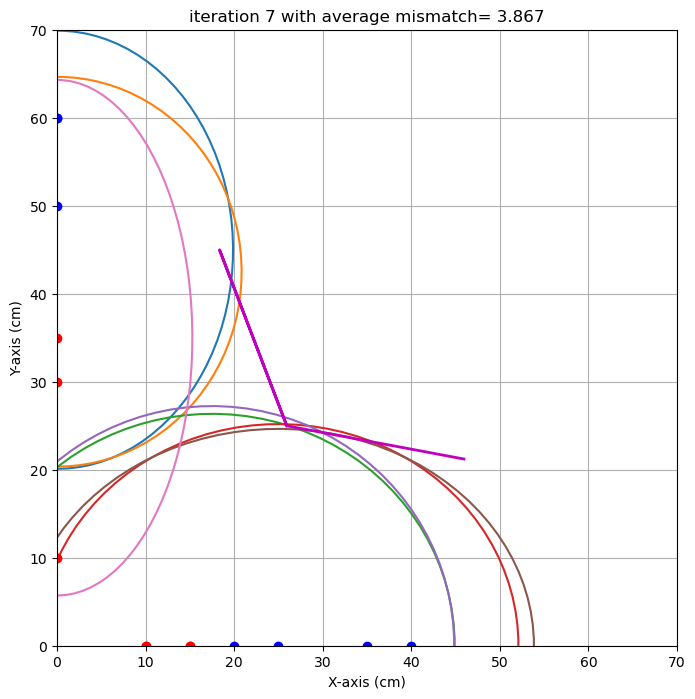

end iteration 7 with average mismatch= 3.867
end iteration 8 with average mismatch= 3.863


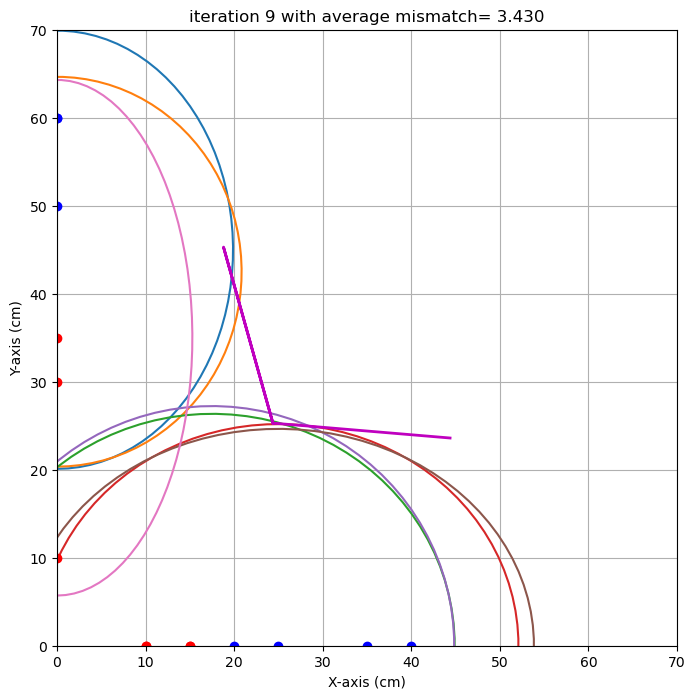

end iteration 9 with average mismatch= 3.430


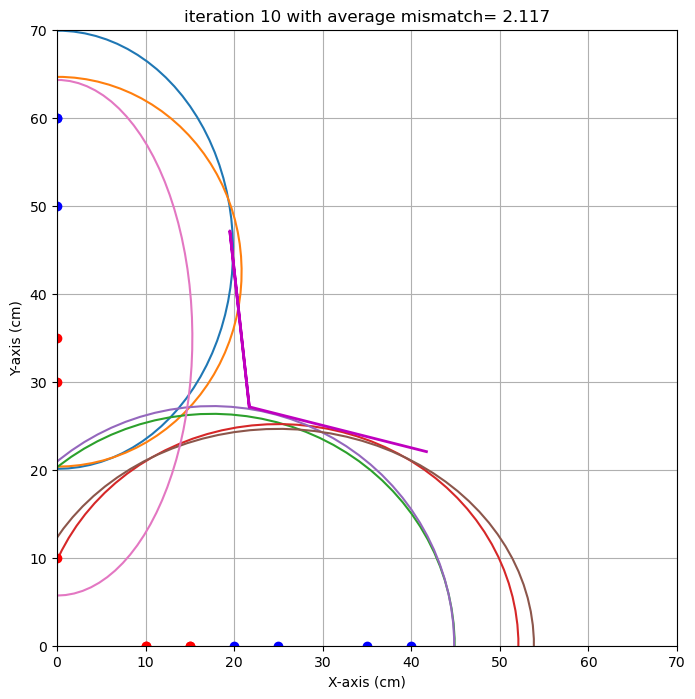

end iteration 10 with average mismatch= 2.117
end iteration 11 with average mismatch= 2.084
end iteration 12 with average mismatch= 1.927
end iteration 13 with average mismatch= 1.924
end iteration 14 with average mismatch= 1.768
end iteration 15 with average mismatch= 1.733


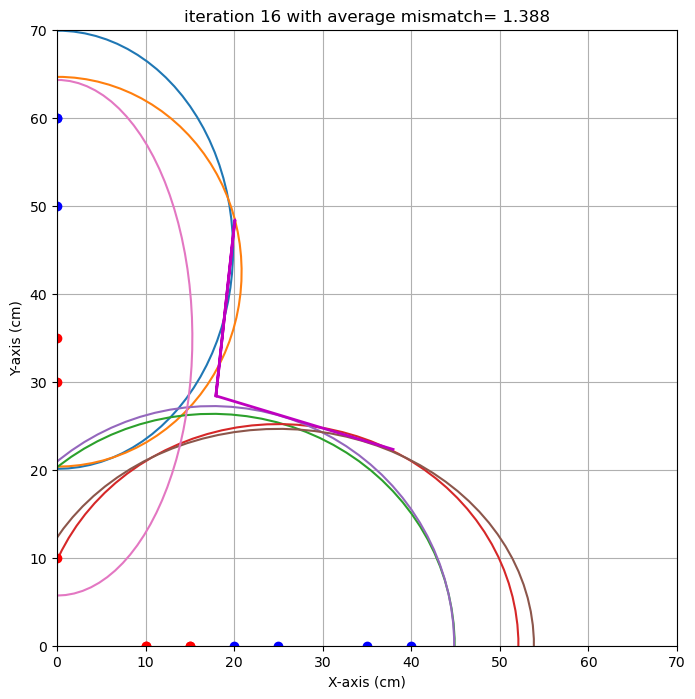

end iteration 16 with average mismatch= 1.388
end iteration 17 with average mismatch= 1.288
end iteration 18 with average mismatch= 1.279


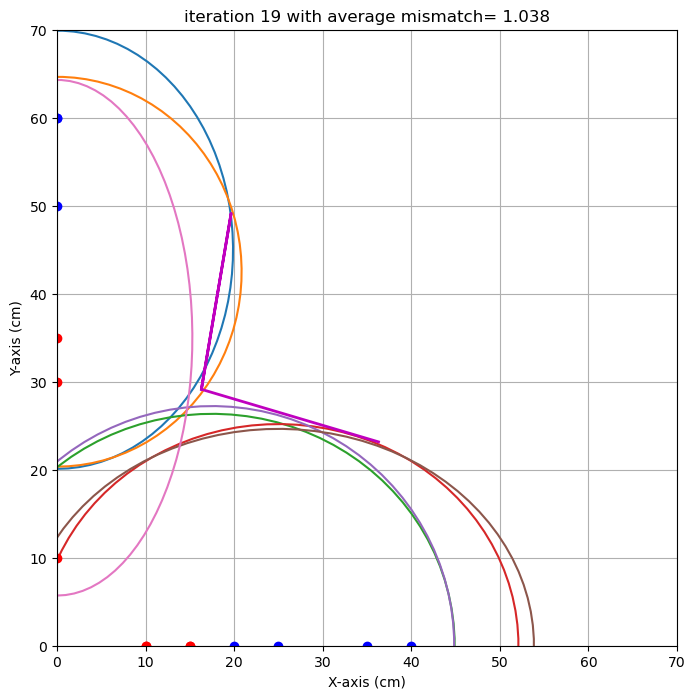

end iteration 19 with average mismatch= 1.038


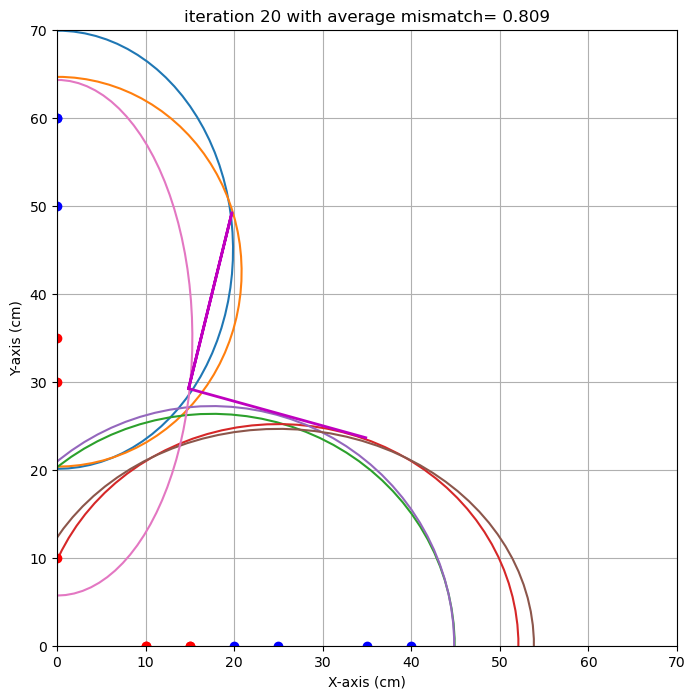

end iteration 20 with average mismatch= 0.809
end iteration 21 with average mismatch= 0.763
end iteration 22 with average mismatch= 0.754
end iteration 23 with average mismatch= 0.754
end iteration 24 with average mismatch= 0.743
end iteration 25 with average mismatch= 0.692
end iteration 26 with average mismatch= 0.681
end iteration 27 with average mismatch= 0.679
end iteration 28 with average mismatch= 0.679
end iteration 29 with average mismatch= 0.679
Last iteration, also determine uncertainty, wait a while..
wait a little longer....
wait a little longer....
wait a little longer....
wait a little longer....
end iteration 30 with average mismatch= 0.679
###############################################################################
end of iteration  30
Best alpha= -15.23 with uncertainty=   0.00
Best beta =  13.58 with uncertainty=   0.00
Best x0   =  14.85 with uncertainty=   0.00
Best y0   =  28.99 with uncertainty=   0.00
##########################################################

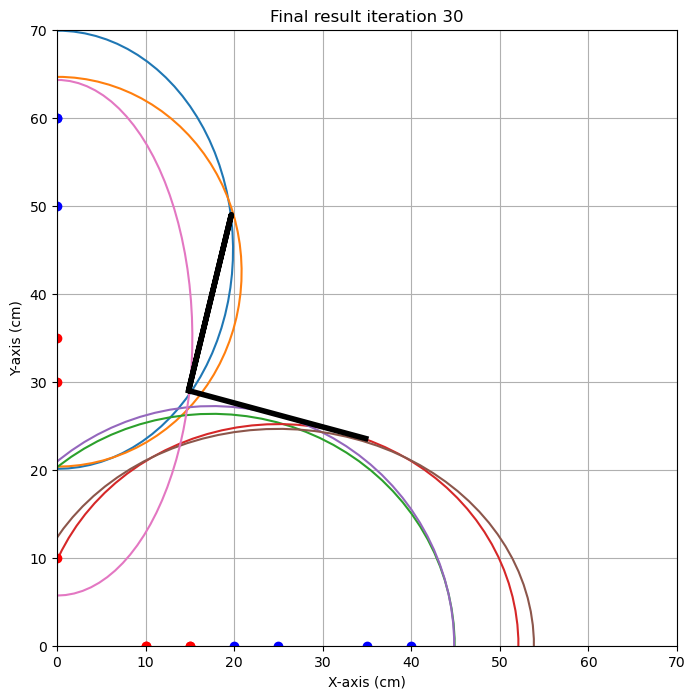

{'alpha': np.float64(-15.225469916235053), 'alpha_eps': 0.0, 'beta': np.float64(13.57718734431403), 'beta_eps': 0.0, 'x0': np.float64(14.849701635363822), 'x0_eps': 0.0, 'y0': np.float64(28.98733138998738), 'y0_eps': 0.0}
test locatie 
x0 target is : 22.0. Gevonden waarde: 14.8 cm met een standaardafwijking van 0.0 cm 
y0 target is : 30.0. Gevonden waarde: 29.0 cm met een standaardafwijking van 0.0 cm 
alpha target is : -10.0. Gevonden waarde: -15.2 graden met een standaardafwijking van 0.0 graad 
beta target is : 10.0. Gevonden waarde: 13.6 graden met een standaardafwijking van 0.0 graad 



In [12]:
# Voeg hier je meetgegevens van de uiteindelijke test in:

# Vul onderstaande in met jullie locaties van het reflecterende papier gegeven
# door jullie TA
targets = {'test locatie':{
                    'x0':  22,
                    'y0':  30,
                    'alpha' : -10,
                    'beta' :  10,
                          }
            }
           

# Vul onderstaande matrixen aan met je gemeten meetgegevens.

dataFinalCheck ={'test locatie' :  pd.DataFrame(columns=["xs", "ys", "xr", "yr", "R"], data=[
    #[0, 40, 40, 0, 51.6],
    #[0,40,0,60,50.8],
    [0,30,0,60, 49.8],
    [0,35,0,50,44.3],
    #[0,50,0,60,47.0],
    [10,0,25,0, 54.8],
    [15,0,35,0, 54.2],
    [15,0,20,0,54.7],
    [10,0,40,0, 57.7],
    #
    # [50,0,20,0, 55.6],
    #[0,25,0,50,45.4],
    [0,10,0,60,58.6],
    #[30,0,45,0, 50.1]

                    ])
                }
 
# Hier runnen we het imaging algoritme:
resultaat = dict()

for locatie in targets:
    print(locatie)
    resultaat[locatie] = imagingDEF.imagingDEF(dataFinalCheck[locatie])
    print(resultaat[locatie])

    
# Run deze cel om jullie resultaten naast elkaar te kunnen zien.
for locatie in targets:
    txt = '{naam} \r\nx0 target is : {x0Target:.1f}. Gevonden waarde: {x0:.1f} cm met een standaardafwijking van {x0_eps:.1f} cm \r\n'
    txt = txt + 'y0 target is : {y0Target:.1f}. Gevonden waarde: {y0:.1f} cm met een standaardafwijking van {y0_eps:.1f} cm \r\n'
    txt = txt + 'alpha target is : {alphaTarget:.1f}. Gevonden waarde: {alpha:.1f} graden met een standaardafwijking van {alpha_eps:.1f} graad \r\n'
    txt = txt + 'beta target is : {betaTarget:.1f}. Gevonden waarde: {beta:.1f} graden met een standaardafwijking van {beta_eps:.1f} graad \r\n'
    print(txt.format(naam = locatie,
                     x0Target=targets[locatie]['x0'],
                     x0=resultaat[locatie]['x0'],
                     x0_eps=resultaat[locatie]['x0_eps'],
                     y0Target=targets[locatie]['y0'],
                     y0=resultaat[locatie]['y0'],
                     y0_eps=resultaat[locatie]['y0_eps'],
                     alphaTarget=targets[locatie]['alpha'],
                     alpha=resultaat[locatie]['alpha'],
                     alpha_eps=resultaat[locatie]['alpha_eps'],
                     betaTarget=targets[locatie]['beta'],
                     beta=resultaat[locatie]['beta'],
                     beta_eps=resultaat[locatie]['beta_eps']))

Conclusie

Door tijdtekort, hebben wij meerdere malen geitereerd, en komen constant binnen alle eisen die gesteld zijn, behalve dat de x0 target telkens flink ernaast zit, maar wel met de juiste standaardafwijking. Dit is telkens te zien bij elke itteratiestap, dat x0 er ver naast zit. Dit is besproken met de TA, en wij kunnen concluderen dat dit heeft gelegen aan een foutieve kalibratie aan het begin. In het vervolg zullen we nauwkeuriger kalibreren, zodat dit zich niet weer voordoet. Verder zitten we binnen alle eisen met flink wat meetpunten, alle hoeken handmatig gemeten en x0 en y0 handmatig afgelezen. Ook hebben wij ons telkens aan het stappenplan gehouden en deze verder geitereerd, welke hieronder te zien is bij de leerdoelen:

## Opdracht 11: Leerdoelen.
Figuur: ![Alt](AlgoritmeDEF4moi.jpg "Orgineel plan")

Figuur: ![Alt](Itteratie2blokschema.jpg "Uiteindelijk blokschema")

We hebben als itteratie steeds meer meetpunten toegevoegd, deze hebben we meteen in hetzlefde blokschema gezet dit is dus het proiduct van meerdere itteraties.

